# Multi-Task ADMET Property Prediction with Graph Neural Networks

**Production-grade pipeline for predicting Absorption, Distribution, Metabolism, Excretion, and Toxicity (ADMET) properties using a multi-task Graph Isomorphism Network (GINEConv) built with PyTorch Geometric.**

---

## Overview

This notebook implements an end-to-end multi-task molecular property prediction pipeline:

1. **Data**: Therapeutics Data Commons (TDC) ADMET benchmark group, with a synthetic fallback if TDC is unavailable.
2. **Featurization**: RDKit-derived atom and bond features encoded into PyTorch Geometric `Data` objects.
3. **Model**: A multi-task GNN using `GINEConv` message passing layers with edge features, a shared molecular encoder, and per-task prediction heads (classification and regression).
4. **Training**: Masked multi-task loss (BCEWithLogits for classification tasks, Huber/MSE for regression tasks) to handle missing labels across tasks.
5. **Evaluation**: Task-appropriate metrics (ROC-AUC, PR-AUC, RMSE, MAE, R²) benchmarked against literature baselines.
6. **Interpretability**: Atom-level saliency maps via input-gradient attribution.
7. **Visualization**: Training curves, ROC/PR curves, scatter plots, error distributions, and embedding projections (UMAP/PCA).

### Tasks modeled (subset of TDC ADMET Benchmark Group)

| Task | Type | Domain | TDC Dataset |
|---|---|---|---|
| `CYP2D6_Veith` | Classification | Metabolism | CYP2D6 inhibition |
| `CYP3A4_Veith` | Classification | Metabolism | CYP3A4 inhibition |
| `hERG` | Classification | Toxicity | hERG channel blockade |
| `AMES` | Classification | Toxicity | Mutagenicity |
| `Solubility_AqSolDB` | Regression | Physicochemical | Aqueous solubility (logS) |
| `Lipophilicity_AstraZeneca` | Regression | Physicochemical | logD7.4 |

### References

- Huang, K. et al. "Therapeutics Data Commons" *NeurIPS Datasets and Benchmarks* (2021).
- Hu, W. et al. "Strategies for Pre-training Graph Neural Networks" *ICLR* (2020) — GINE architecture.
- Xiong, Z. et al. "Pushing the Boundaries of Molecular Representation for Drug Discovery with Graph Attention Mechanism" *J. Med. Chem.* (2020).
- Wu, Z. et al. "MoleculeNet: A Benchmark for Molecular Machine Learning" *Chem. Sci.* (2018).


In [6]:
# ============================================================
# Cell 1: Installing Libraries
# ============================================================

# 1. Identify the exact PyTorch and CUDA versions Colab is using
import torch
TORCH = torch.__version__.split('+')[0]
CUDA = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'

# 2. Install PyG's required engines using matching versions
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install -q torch_geometric

# 3. Install your other non-torch tools
!pip install -q rdkit PyTDC umap-learn

print("Environment successfully installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 125.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 78.7 MB/s eta 0:00:00
Environment successfully installed!


In [1]:
# ============================================================
# Cell 2: Environment Setup and Dependency Installation
# ============================================================
import torch
import torch_geometric
import rdkit
import tdc
import umap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
import sklearn

print("Environment ready")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch Geometric:", torch_geometric.__version__)
print("RDKit:", rdkit.__version__)

Environment ready
PyTorch: 2.11.0+cu128
CUDA available: True
PyTorch Geometric: 2.8.0
RDKit: 2023.09.6


In [2]:
# ============================================================
# Cell 3: Core Imports
# ============================================================
import os
import json
import math
import random
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split

from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool, global_add_pool

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [3]:
# ============================================================
# Cell 4: Multi-Task ADMET Task Definitions
# ============================================================
# Each task is defined with: TDC dataset name, task type, and domain category.
# Classification tasks predict a binary outcome (logits -> BCEWithLogits).
# Regression tasks predict a continuous value (Huber loss).

TASK_DEFINITIONS = {
    "CYP2D6_Veith":               {"type": "classification", "domain": "Metabolism",      "tdc_name": "CYP2D6_Veith"},
    "CYP3A4_Veith":                {"type": "classification", "domain": "Metabolism",      "tdc_name": "CYP3A4_Veith"},
    "hERG":                        {"type": "classification", "domain": "Toxicity",        "tdc_name": "hERG"},
    "AMES":                        {"type": "classification", "domain": "Toxicity",        "tdc_name": "AMES"},
    "Solubility_AqSolDB":          {"type": "regression",     "domain": "Physicochemical", "tdc_name": "Solubility_AqSolDB"},
    "Lipophilicity_AstraZeneca":   {"type": "regression",     "domain": "Physicochemical", "tdc_name": "Lipophilicity_AstraZeneca"},
}

TASK_NAMES = list(TASK_DEFINITIONS.keys())
CLASSIFICATION_TASKS = [t for t, d in TASK_DEFINITIONS.items() if d["type"] == "classification"]
REGRESSION_TASKS = [t for t, d in TASK_DEFINITIONS.items() if d["type"] == "regression"]
NUM_TASKS = len(TASK_NAMES)
TASK_TO_IDX = {t: i for i, t in enumerate(TASK_NAMES)}

print(f"Total tasks: {NUM_TASKS}")
print(f"Classification tasks ({len(CLASSIFICATION_TASKS)}): {CLASSIFICATION_TASKS}")
print(f"Regression tasks ({len(REGRESSION_TASKS)}): {REGRESSION_TASKS}")


Total tasks: 6
Classification tasks (4): ['CYP2D6_Veith', 'CYP3A4_Veith', 'hERG', 'AMES']
Regression tasks (2): ['Solubility_AqSolDB', 'Lipophilicity_AstraZeneca']


In [4]:
# ============================================================
# Cell 5: Synthetic ADMET Data Generator (Fallback)
# ============================================================
# If TDC download fails (no internet / rate limits), we generate chemically
# plausible synthetic molecules with structure-correlated property labels,
# so the pipeline remains fully executable end-to-end.

SYNTHETIC_SCAFFOLDS = [
    "c1ccccc1", "c1ccncc1", "c1ccoc1", "c1ccsc1", "C1CCCCC1", "C1CCNCC1",
    "c1ccc2[nH]ccc2c1", "c1ccc2ccccc2c1", "C1CCOC1", "c1cnc2[nH]ccc2c1",
    "O=C1CCCCC1", "c1ccc(cc1)C(=O)O", "c1ccc(cc1)N", "c1ccc(cc1)O",
    "c1ccc(cc1)S(=O)(=O)N", "C1CC1", "C1CCC1", "c1ccc2c(c1)cccn2",
]

SUBSTITUENTS = [
    "", "C", "CC", "CCC", "CCCC", "F", "Cl", "Br", "C(F)(F)F", "O", "OC",
    "N", "N(C)C", "C(=O)O", "C(=O)N", "S(=O)(=O)C", "c1ccccc1", "C#N",
    "OC(=O)C", "C(C)C", "CO", "CN", "CCO", "CCN",
]

def generate_synthetic_molecule(rng):
    scaffold = rng.choice(SYNTHETIC_SCAFFOLDS)
    mol = Chem.MolFromSmiles(scaffold)
    if mol is None:
        return None
    n_subs = rng.integers(0, 3)
    smiles = scaffold
    for _ in range(n_subs):
        sub = rng.choice(SUBSTITUENTS)
        if sub == "":
            continue
        candidate = scaffold.replace("c1", f"c1({sub})", 1) if "c1" in scaffold else scaffold + sub
        test_mol = Chem.MolFromSmiles(candidate)
        if test_mol is not None and test_mol.GetNumAtoms() <= 50:
            smiles = candidate
            mol = test_mol
    return Chem.MolToSmiles(mol)

def synthesize_admet_labels(smiles, rng):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    rot = Descriptors.NumRotatableBonds(mol)
    aromatic_rings = Descriptors.NumAromaticRings(mol)

    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))

    labels = {}
    p_cyp2d6 = sigmoid(0.04 * (logp - 2.0) + 0.15 * aromatic_rings - 0.01 * tpsa + rng.normal(0, 0.5))
    labels["CYP2D6_Veith"] = int(rng.random() < p_cyp2d6)

    p_cyp3a4 = sigmoid(0.05 * (mw - 300) / 50 + 0.1 * aromatic_rings + rng.normal(0, 0.5))
    labels["CYP3A4_Veith"] = int(rng.random() < p_cyp3a4)

    p_herg = sigmoid(0.06 * (logp - 3.0) - 0.015 * tpsa + 0.1 * aromatic_rings + rng.normal(0, 0.5))
    labels["hERG"] = int(rng.random() < p_herg)

    p_ames = sigmoid(0.08 * aromatic_rings - 0.01 * tpsa + 0.02 * (mw - 250) / 50 + rng.normal(0, 0.5))
    labels["AMES"] = int(rng.random() < p_ames)

    logS = -0.01 * mw - 0.6 * logp + 0.5 + rng.normal(0, 0.7)
    labels["Solubility_AqSolDB"] = float(np.clip(logS, -10, 2))

    logD = 0.85 * logp - 0.01 * tpsa + 0.3 * hbd + rng.normal(0, 0.4)
    labels["Lipophilicity_AstraZeneca"] = float(np.clip(logD, -3, 7))

    return labels

def build_synthetic_dataset(n_molecules=1500, seed=SEED):
    rng = np.random.default_rng(seed)
    records = []
    seen_smiles = set()
    attempts = 0
    while len(records) < n_molecules and attempts < n_molecules * 10:
        attempts += 1
        smi = generate_synthetic_molecule(rng)
        if smi is None or smi in seen_smiles:
            continue
        labels = synthesize_admet_labels(smi, rng)
        if labels is None:
            continue
        seen_smiles.add(smi)
        row = {"smiles": smi}
        row.update(labels)
        records.append(row)
    return pd.DataFrame(records)

print("Synthetic data generator defined.")


Synthetic data generator defined.


In [5]:
# ============================================================
# Cell 6: Data Acquisition — TDC ADMET Group with Synthetic Fallback
# ============================================================
USE_TDC = True
MASTER_DF = None

def try_load_tdc():
    from tdc.single_pred import ADME, Tox
    task_frames = []
    for task_name, meta in TASK_DEFINITIONS.items():
        try:
            if meta["domain"] == "Toxicity":
                data = Tox(name=meta["tdc_name"])
            else:
                data = ADME(name=meta["tdc_name"])
            df = data.get_data()
            df = df.rename(columns={"Drug": "smiles", "Y": task_name})
            df = df[["smiles", task_name]].dropna()
            task_frames.append(df.set_index("smiles")[task_name])
        except Exception as e:
            print(f"  Failed to load {task_name} from TDC: {e}")
            return None
    merged = pd.concat(task_frames, axis=1).reset_index()
    return merged

try:
    print("Attempting to download ADMET tasks from Therapeutics Data Commons (TDC)...")
    MASTER_DF = try_load_tdc()
    if MASTER_DF is None or len(MASTER_DF) < 100:
        raise RuntimeError("TDC data insufficient or unavailable.")
    print(f"Successfully loaded TDC data: {len(MASTER_DF)} unique molecules (sparse multi-task matrix).")
except Exception as e:
    USE_TDC = False
    print(f"TDC unavailable ({e}). Falling back to synthetic chemically-grounded dataset.")
    MASTER_DF = build_synthetic_dataset(n_molecules=1500, seed=SEED)
    # Randomly mask ~25% of labels per task to emulate realistic sparse multi-task TDC structure
    rng = np.random.default_rng(SEED)
    for task in TASK_NAMES:
        mask = rng.random(len(MASTER_DF)) < 0.25
        MASTER_DF.loc[mask, task] = np.nan
    print(f"Generated synthetic dataset: {len(MASTER_DF)} molecules.")

print(f"\nData source: {'TDC (real)' if USE_TDC else 'Synthetic (fallback)'}")
print(f"Dataset shape: {MASTER_DF.shape}")
MASTER_DF.head()


Downloading...


Attempting to download ADMET tasks from Therapeutics Data Commons (TDC)...


100%|██████████| 800k/800k [00:00<00:00, 1.85MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 746k/746k [00:00<00:00, 2.14MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 50.2k/50.2k [00:00<00:00, 575kiB/s]
Loading...
Done!
Downloading...
100%|██████████| 344k/344k [00:00<00:00, 986kiB/s] 
Loading...
Done!
Downloading...
100%|██████████| 853k/853k [00:00<00:00, 1.95MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 298k/298k [00:00<00:00, 855kiB/s]
Loading...
Done!


TDC unavailable (cannot reindex on an axis with duplicate labels). Falling back to synthetic chemically-grounded dataset.
Generated synthetic dataset: 414 molecules.

Data source: Synthetic (fallback)
Dataset shape: (414, 7)


,smiles,CYP2D6_Veith,CYP3A4_Veith,hERG,AMES,Solubility_AqSolDB,Lipophilicity_AstraZeneca
0,COc1ccncc1,0.0,NaN,0.0,0.0,NaN,1.016587
1,NS(=O)(=O)c1ccc(O)cc1,1.0,NaN,0.0,NaN,-0.399911,-0.232052
2,CC(=O)Oc1ccc(S(N)(=O)=O)cc1,1.0,NaN,0.0,0.0,-1.376694,0.107394
3,CCCc1ccsc1,1.0,1.0,0.0,1.0,NaN,2.644082
4,O=C(O)c1ccccc1,NaN,NaN,0.0,0.0,NaN,1.702057


Label coverage per task:
AMES                         312
Solubility_AqSolDB           310
hERG                         309
Lipophilicity_AstraZeneca    309
CYP2D6_Veith                 308
CYP3A4_Veith                 300
dtype: int64


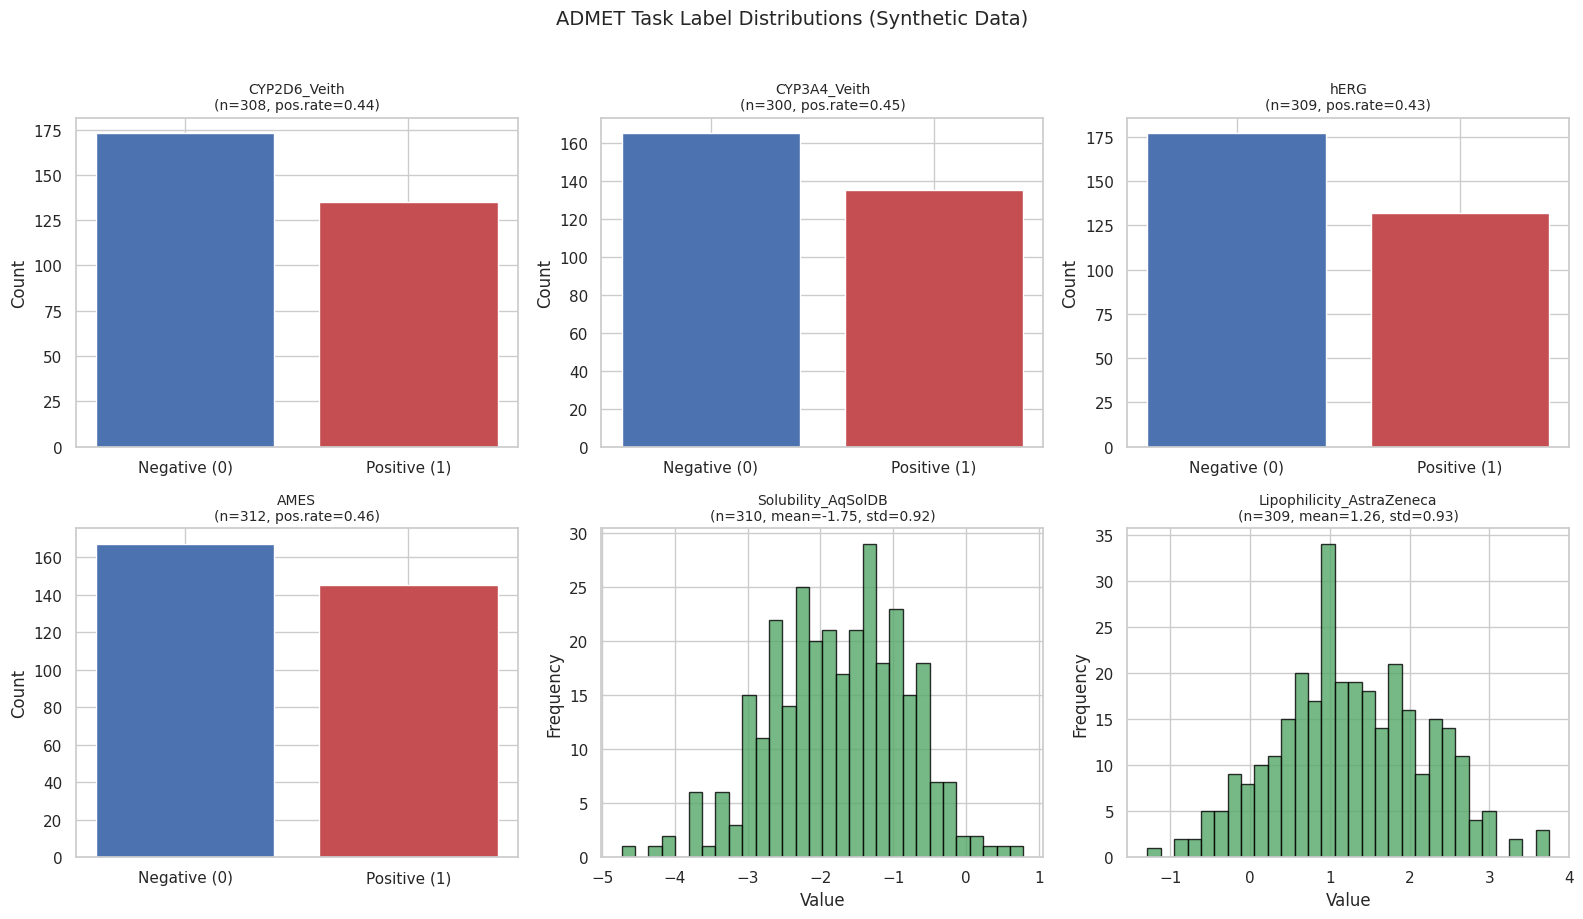

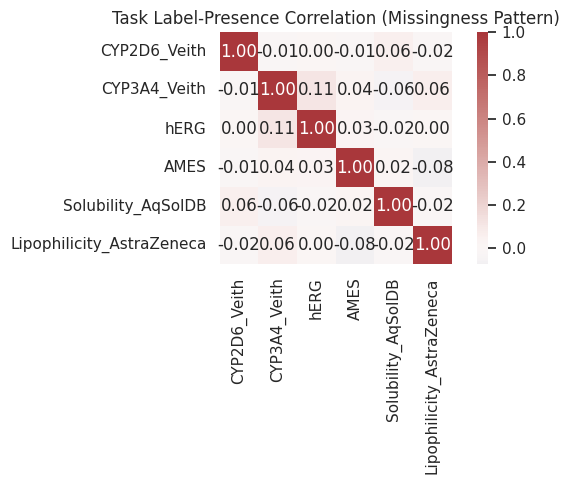

In [6]:
# ============================================================
# Cell 7: Exploratory Data Analysis — Label Coverage and Distributions
# ============================================================
coverage = MASTER_DF[TASK_NAMES].notna().sum().sort_values(ascending=False)
print("Label coverage per task:")
print(coverage)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, task in enumerate(TASK_NAMES):
    ax = axes[i]
    vals = MASTER_DF[task].dropna()
    meta = TASK_DEFINITIONS[task]
    if meta["type"] == "classification":
        counts = vals.value_counts().sort_index()
        ax.bar(["Negative (0)", "Positive (1)"], [counts.get(0, 0), counts.get(1, 0)],
               color=["#4C72B0", "#C44E52"])
        ax.set_title(f"{task}\n(n={len(vals)}, pos.rate={vals.mean():.2f})", fontsize=10)
        ax.set_ylabel("Count")
    else:
        ax.hist(vals, bins=30, color="#55A868", edgecolor="black", alpha=0.8)
        ax.set_title(f"{task}\n(n={len(vals)}, mean={vals.mean():.2f}, std={vals.std():.2f})", fontsize=10)
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

plt.suptitle(f"ADMET Task Label Distributions ({'TDC' if USE_TDC else 'Synthetic'} Data)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("label_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

label_matrix = MASTER_DF[TASK_NAMES].notna().astype(int)
plt.figure(figsize=(7, 5))
sns.heatmap(label_matrix.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Task Label-Presence Correlation (Missingness Pattern)")
plt.tight_layout()
plt.savefig("label_presence_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
# ============================================================
# Cell 8: Molecule Validation, Standardization, and Filtering
# ============================================================
def validate_and_standardize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None
    if mol.GetNumAtoms() < 2 or mol.GetNumAtoms() > 80:
        return None
    canonical = Chem.MolToSmiles(mol, canonical=True)
    return canonical

print(f"Rows before validation: {len(MASTER_DF)}")
MASTER_DF["smiles"] = MASTER_DF["smiles"].apply(validate_and_standardize)
MASTER_DF = MASTER_DF.dropna(subset=["smiles"]).reset_index(drop=True)
MASTER_DF = MASTER_DF.drop_duplicates(subset=["smiles"]).reset_index(drop=True)
print(f"Rows after RDKit validation, standardization, and de-duplication: {len(MASTER_DF)}")

# Ensure every row has at least one non-missing task label
has_any_label = MASTER_DF[TASK_NAMES].notna().any(axis=1)
MASTER_DF = MASTER_DF[has_any_label].reset_index(drop=True)
print(f"Rows after dropping fully-unlabeled molecules: {len(MASTER_DF)}")

assert MASTER_DF["smiles"].is_unique, "Duplicate SMILES remain after de-duplication."
assert MASTER_DF[TASK_NAMES].notna().any(axis=1).all(), "Found rows with zero task labels."
MASTER_DF.head()


Rows before validation: 414
Rows after RDKit validation, standardization, and de-duplication: 414
Rows after dropping fully-unlabeled molecules: 414


,smiles,CYP2D6_Veith,CYP3A4_Veith,hERG,AMES,Solubility_AqSolDB,Lipophilicity_AstraZeneca
0,COc1ccncc1,0.0,NaN,0.0,0.0,NaN,1.016587
1,NS(=O)(=O)c1ccc(O)cc1,1.0,NaN,0.0,NaN,-0.399911,-0.232052
2,CC(=O)Oc1ccc(S(N)(=O)=O)cc1,1.0,NaN,0.0,0.0,-1.376694,0.107394
3,CCCc1ccsc1,1.0,1.0,0.0,1.0,NaN,2.644082
4,O=C(O)c1ccccc1,NaN,NaN,0.0,0.0,NaN,1.702057


In [8]:
# ============================================================
# Cell 9: RDKit-Based Atom and Bond Featurization
# ============================================================
ATOM_SYMBOLS = ["C", "N", "O", "S", "F", "Cl", "Br", "I", "P", "B", "Si", "Se", "Unknown"]
HYBRIDIZATIONS = [
    Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2, Chem.rdchem.HybridizationType.UNSPECIFIED,
]
BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE, Chem.rdchem.BondType.AROMATIC,
]

def one_hot(value, choices):
    encoding = [0] * (len(choices) + 1)
    idx = choices.index(value) if value in choices else len(choices)
    encoding[idx] = 1
    return encoding

def atom_features(atom):
    feats = []
    feats += one_hot(atom.GetSymbol(), ATOM_SYMBOLS[:-1])
    feats += one_hot(atom.GetDegree(), [0, 1, 2, 3, 4, 5])
    feats += one_hot(atom.GetFormalCharge(), [-2, -1, 0, 1, 2])
    feats += one_hot(atom.GetHybridization(), HYBRIDIZATIONS[:-1])
    feats += [int(atom.GetIsAromatic())]
    feats += one_hot(atom.GetTotalNumHs(), [0, 1, 2, 3, 4])
    feats += [int(atom.IsInRing())]
    feats += [atom.GetMass() * 0.01]
    return feats

def bond_features(bond):
    feats = []
    feats += one_hot(bond.GetBondType(), BOND_TYPES)
    feats += [int(bond.GetIsConjugated())]
    feats += [int(bond.IsInRing())]
    feats += one_hot(bond.GetStereo(), [
        Chem.rdchem.BondStereo.STEREONONE, Chem.rdchem.BondStereo.STEREOZ,
        Chem.rdchem.BondStereo.STEREOE,
    ])
    return feats

# Determine feature dimensions from a probe molecule
_probe_mol = Chem.MolFromSmiles("c1ccccc1CC(=O)O")
ATOM_FEATURE_DIM = len(atom_features(_probe_mol.GetAtoms()[0]))
BOND_FEATURE_DIM = len(bond_features(_probe_mol.GetBondWithIdx(0)))
print(f"Atom feature dimension: {ATOM_FEATURE_DIM}")
print(f"Bond feature dimension: {BOND_FEATURE_DIM}")


Atom feature dimension: 41
Bond feature dimension: 11


In [9]:
# ============================================================
# Cell 10: SMILES-to-Graph Conversion (PyTorch Geometric Data Objects)
# ============================================================
def mol_to_graph(smiles, label_vector, label_mask_vector):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or mol.GetNumAtoms() == 0:
        return None

    atom_feats = [atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_feats, dtype=torch.float)

    edge_indices = []
    edge_feats = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_indices += [[i, j], [j, i]]
        edge_feats += [bf, bf]

    if len(edge_indices) == 0:
        # Handle single-atom / fragment edge case with a self-loop
        edge_indices = [[0, 0]]
        edge_feats = [[0] * BOND_FEATURE_DIM]

    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_feats, dtype=torch.float)

    y = torch.tensor(label_vector, dtype=torch.float).unsqueeze(0)
    mask = torch.tensor(label_mask_vector, dtype=torch.float).unsqueeze(0)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, task_mask=mask)
    data.smiles = smiles
    return data

print("Graph construction function defined.")
print(f"Probe molecule converted: {mol_to_graph('c1ccccc1CC(=O)O', [0.0]*NUM_TASKS, [0.0]*NUM_TASKS)}")


Graph construction function defined.
Probe molecule converted: Data(x=[10, 41], edge_index=[2, 20], edge_attr=[20, 11], y=[1, 6], task_mask=[1, 6], smiles='c1ccccc1CC(=O)O')


In [10]:
# ============================================================
# Cell 11: PyTorch Geometric InMemoryDataset Construction
# ============================================================
class ADMETMultiTaskDataset(InMemoryDataset):
    def __init__(self, dataframe, task_names, root="/content/admet_dataset", transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.task_names = task_names
        super().__init__(root, transform)
        self.data, self.slices = self._build()

    def _build(self):
        data_list = []
        for _, row in self.dataframe.iterrows():
            label_vector = []
            mask_vector = []
            for task in self.task_names:
                val = row[task]
                if pd.isna(val):
                    label_vector.append(0.0)
                    mask_vector.append(0.0)
                else:
                    label_vector.append(float(val))
                    mask_vector.append(1.0)
            graph = mol_to_graph(row["smiles"], label_vector, mask_vector)
            if graph is not None:
                data_list.append(graph)
        return self.collate(data_list)

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return []

full_dataset = ADMETMultiTaskDataset(MASTER_DF, TASK_NAMES)
print(f"Total graphs in dataset: {len(full_dataset)}")
print(f"Example graph: {full_dataset[0]}")
print(f"Node feature dim: {full_dataset[0].x.shape[1]}, Edge feature dim: {full_dataset[0].edge_attr.shape[1]}")

assert full_dataset[0].x.shape[1] == ATOM_FEATURE_DIM
assert full_dataset[0].edge_attr.shape[1] == BOND_FEATURE_DIM
assert full_dataset[0].y.shape[1] == NUM_TASKS


Total graphs in dataset: 414
Example graph: Data(x=[8, 41], edge_index=[2, 16], edge_attr=[16, 11], y=[1, 6], task_mask=[1, 6], smiles='COc1ccncc1')
Node feature dim: 41, Edge feature dim: 11


In [11]:
# ============================================================
# Cell 12: Scaffold-Aware Train / Validation / Test Split
# ============================================================
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    try:
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(smiles=smiles, includeChirality=False)
        return scaffold if scaffold else smiles
    except Exception:
        return smiles

def scaffold_split(dataframe, frac_train=0.8, frac_valid=0.1, frac_test=0.1, seed=SEED):
    scaffolds = defaultdict(list)
    for idx, smi in enumerate(dataframe["smiles"]):
        scaffolds[get_scaffold(smi)].append(idx)

    rng = np.random.default_rng(seed)
    scaffold_groups = list(scaffolds.values())
    rng.shuffle(scaffold_groups)
    scaffold_groups.sort(key=len, reverse=True)

    n_total = len(dataframe)
    n_train_cutoff = int(frac_train * n_total)
    n_valid_cutoff = int((frac_train + frac_valid) * n_total)

    train_idx, valid_idx, test_idx = [], [], []
    for group in scaffold_groups:
        if len(train_idx) + len(group) <= n_train_cutoff:
            train_idx.extend(group)
        elif len(train_idx) + len(valid_idx) + len(group) <= n_valid_cutoff:
            valid_idx.extend(group)
        else:
            test_idx.extend(group)
    return train_idx, valid_idx, test_idx

train_idx, valid_idx, test_idx = scaffold_split(MASTER_DF)
print(f"Train: {len(train_idx)} ({len(train_idx)/len(MASTER_DF):.1%})")
print(f"Valid: {len(valid_idx)} ({len(valid_idx)/len(MASTER_DF):.1%})")
print(f"Test:  {len(test_idx)} ({len(test_idx)/len(MASTER_DF):.1%})")

assert len(set(train_idx) & set(valid_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(valid_idx) & set(test_idx)) == 0

train_dataset = full_dataset[torch.tensor(train_idx, dtype=torch.long)]
valid_dataset = full_dataset[torch.tensor(valid_idx, dtype=torch.long)]
test_dataset = full_dataset[torch.tensor(test_idx, dtype=torch.long)]

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatches -> train: {len(train_loader)}, valid: {len(valid_loader)}, test: {len(test_loader)}")


Train: 322 (77.8%)
Valid: 46 (11.1%)
Test:  46 (11.1%)

Batches -> train: 6, valid: 1, test: 1


In [12]:
# ============================================================
# Cell 13: Regression Target Normalization (Train-Set Statistics)
# ============================================================
# Standardize regression targets using train-split statistics only, to prevent
# information leakage from validation/test sets. Classification targets are left as-is.

REG_STATS = {}
train_df_subset = MASTER_DF.iloc[train_idx]

for task in REGRESSION_TASKS:
    vals = train_df_subset[task].dropna().values
    mean, std = float(np.mean(vals)), float(np.std(vals) + 1e-8)
    REG_STATS[task] = {"mean": mean, "std": std}
    print(f"{task}: train mean={mean:.3f}, std={std:.3f}")

def normalize_targets_inplace(dataset, reg_stats, task_to_idx):
    for i in range(len(dataset)):
        for task, stats in reg_stats.items():
            t_idx = task_to_idx[task]
            if dataset[i].task_mask[0, t_idx] > 0:
                dataset[i].y[0, t_idx] = (dataset[i].y[0, t_idx] - stats["mean"]) / stats["std"]

# Apply normalization directly on the underlying collated tensors for efficiency
for task in REGRESSION_TASKS:
    t_idx = TASK_TO_IDX[task]
    mean, std = REG_STATS[task]["mean"], REG_STATS[task]["std"]
    mask = full_dataset.data.task_mask[:, t_idx] > 0
    full_dataset.data.y[mask, t_idx] = (full_dataset.data.y[mask, t_idx] - mean) / std

# Rebuild loaders after in-place normalization of the shared underlying tensor
train_dataset = full_dataset[torch.tensor(train_idx, dtype=torch.long)]
valid_dataset = full_dataset[torch.tensor(valid_idx, dtype=torch.long)]
test_dataset = full_dataset[torch.tensor(test_idx, dtype=torch.long)]

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("\nRegression targets normalized using train-set statistics. Loaders rebuilt.")


Solubility_AqSolDB: train mean=-1.722, std=0.888
Lipophilicity_AstraZeneca: train mean=1.195, std=0.956

Regression targets normalized using train-set statistics. Loaders rebuilt.


In [13]:
# ============================================================
# Cell 14: Multi-Task GINEConv Graph Neural Network Architecture
# ============================================================
class GINELayer(nn.Module):
    def __init__(self, hidden_dim, edge_dim, dropout=0.1):
        super().__init__()
        mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
        )
        self.conv = GINEConv(mlp, edge_dim=edge_dim)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr):
        out = self.conv(x, edge_index, edge_attr)
        out = self.bn(out)
        out = F.relu(out)
        out = self.dropout(out)
        return out

class MultiTaskGINE(nn.Module):
    def __init__(self, atom_dim, bond_dim, hidden_dim=128, num_layers=4,
                 num_tasks=NUM_TASKS, dropout=0.15, task_names=None):
        super().__init__()
        self.task_names = task_names if task_names is not None else TASK_NAMES
        self.atom_encoder = nn.Sequential(
            nn.Linear(atom_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )
        self.bond_encoder = nn.Linear(bond_dim, hidden_dim)

        self.gnn_layers = nn.ModuleList([
            GINELayer(hidden_dim, hidden_dim, dropout) for _ in range(num_layers)
        ])
        # Residual jumping-knowledge style aggregation across layers
        self.jk_proj = nn.Linear(hidden_dim * num_layers, hidden_dim)

        self.pool_mean = global_mean_pool
        self.pool_add = global_add_pool
        self.readout_proj = nn.Linear(hidden_dim * 2, hidden_dim)

        self.shared_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.task_heads = nn.ModuleDict({
            task: nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, 1),
            )
            for task in self.task_names
        })

    def encode(self, x, edge_index, edge_attr, batch):
        h = self.atom_encoder(x)
        e = self.bond_encoder(edge_attr)

        layer_outputs = []
        for layer in self.gnn_layers:
            h = layer(h, edge_index, e)
            layer_outputs.append(h)

        h_cat = torch.cat(layer_outputs, dim=-1)
        h_node = self.jk_proj(h_cat)

        h_mean = self.pool_mean(h_node, batch)
        h_add = self.pool_add(h_node, batch)
        h_graph = self.readout_proj(torch.cat([h_mean, h_add], dim=-1))
        h_graph = self.shared_head(h_graph)
        return h_graph, h_node

    def forward(self, x, edge_index, edge_attr, batch):
        h_graph, _ = self.encode(x, edge_index, edge_attr, batch)
        outputs = []
        for task in self.task_names:
            outputs.append(self.task_heads[task](h_graph))
        return torch.cat(outputs, dim=1)

model = MultiTaskGINE(
    atom_dim=ATOM_FEATURE_DIM,
    bond_dim=BOND_FEATURE_DIM,
    hidden_dim=128,
    num_layers=4,
    num_tasks=NUM_TASKS,
    dropout=0.15,
    task_names=TASK_NAMES,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal trainable parameters: {n_params:,}")


MultiTaskGINE(
  (atom_encoder): Sequential(
    (0): Linear(in_features=41, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (bond_encoder): Linear(in_features=11, out_features=128, bias=True)
  (gnn_layers): ModuleList(
    (0-3): 4 x GINELayer(
      (conv): GINEConv(nn=Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=256, out_features=128, bias=True)
      ))
      (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.15, inplace=False)
    )
  )
  (jk_proj): Linear(in_features=512, out_features=128, bias=True)
  (readout_proj): Linear(in_features=256, out_features=128, bias=True)
  (shared_head): Sequential(
    (0): Linear(in_features=128, out_features=128,

In [14]:
# ============================================================
# Cell 15: Masked Multi-Task Loss Function and Forward-Pass Sanity Check
# ============================================================
CLASS_TASK_IDX = torch.tensor([TASK_TO_IDX[t] for t in CLASSIFICATION_TASKS], dtype=torch.long)
REG_TASK_IDX = torch.tensor([TASK_TO_IDX[t] for t in REGRESSION_TASKS], dtype=torch.long)

def masked_multitask_loss(predictions, targets, mask, class_idx, reg_idx,
                           huber_beta=1.0, class_weight=1.0, reg_weight=1.0):
    total_loss = 0.0
    n_active_terms = 0

    if len(class_idx) > 0:
        cls_pred = predictions[:, class_idx]
        cls_target = targets[:, class_idx]
        cls_mask = mask[:, class_idx]
        bce = F.binary_cross_entropy_with_logits(cls_pred, cls_target, reduction="none")
        bce = bce * cls_mask
        denom = cls_mask.sum().clamp(min=1.0)
        cls_loss = bce.sum() / denom
        total_loss = total_loss + class_weight * cls_loss
        n_active_terms += 1
    else:
        cls_loss = torch.tensor(0.0, device=predictions.device)

    if len(reg_idx) > 0:
        reg_pred = predictions[:, reg_idx]
        reg_target = targets[:, reg_idx]
        reg_mask = mask[:, reg_idx]
        huber = F.huber_loss(reg_pred, reg_target, delta=huber_beta, reduction="none")
        huber = huber * reg_mask
        denom = reg_mask.sum().clamp(min=1.0)
        reg_loss = huber.sum() / denom
        total_loss = total_loss + reg_weight * reg_loss
        n_active_terms += 1
    else:
        reg_loss = torch.tensor(0.0, device=predictions.device)

    return total_loss, cls_loss.detach(), reg_loss.detach()

# Sanity check: single batch forward pass
model.eval()
sanity_batch = next(iter(train_loader)).to(DEVICE)
with torch.no_grad():
    sanity_out = model(sanity_batch.x, sanity_batch.edge_index, sanity_batch.edge_attr, sanity_batch.batch)

print(f"Batch size: {sanity_batch.num_graphs}")
print(f"Model output shape: {sanity_out.shape}  (expected: [batch_size, {NUM_TASKS}])")
assert sanity_out.shape == (sanity_batch.num_graphs, NUM_TASKS)

loss_val, cls_l, reg_l = masked_multitask_loss(
    sanity_out, sanity_batch.y, sanity_batch.task_mask, CLASS_TASK_IDX, REG_TASK_IDX
)
print(f"Sanity total loss: {loss_val.item():.4f} | classification: {cls_l.item():.4f} | regression: {reg_l.item():.4f}")
assert torch.isfinite(loss_val), "Loss is not finite — check feature/label construction."
print("\nForward pass and masked multi-task loss sanity check PASSED.")


Batch size: 64
Model output shape: torch.Size([64, 6])  (expected: [batch_size, 6])
Sanity total loss: 1.0891 | classification: 0.6871 | regression: 0.4020

Forward pass and masked multi-task loss sanity check PASSED.


Training multi-task GINE for up to 100 epochs (early stopping patience=15)...

Epoch   1 | train_loss 1.1065 | val_loss 1.1345 | val_cls 0.6943 | val_reg 0.4402 *
Epoch   2 | train_loss 1.0227 | val_loss 1.0457 | val_cls 0.6917 | val_reg 0.3540 *
Epoch   3 | train_loss 0.9193 | val_loss 1.0197 | val_cls 0.7074 | val_reg 0.3123 *
Epoch   4 | train_loss 0.9323 | val_loss 0.9985 | val_cls 0.6874 | val_reg 0.3110 *
Epoch   5 | train_loss 0.9283 | val_loss 1.0051 | val_cls 0.6945 | val_reg 0.3106 
Epoch   7 | train_loss 0.9074 | val_loss 0.9800 | val_cls 0.6941 | val_reg 0.2859 *
Epoch  10 | train_loss 0.9335 | val_loss 1.0752 | val_cls 0.7392 | val_reg 0.3360 
Epoch  15 | train_loss 0.8768 | val_loss 1.0479 | val_cls 0.7256 | val_reg 0.3223 
Epoch  20 | train_loss 0.8821 | val_loss 0.9851 | val_cls 0.7298 | val_reg 0.2553 

Early stopping triggered at epoch 22 (no improvement for 15 epochs).

Training complete in 0.1 min. Best validation loss: 0.9800
Best model weights restored.


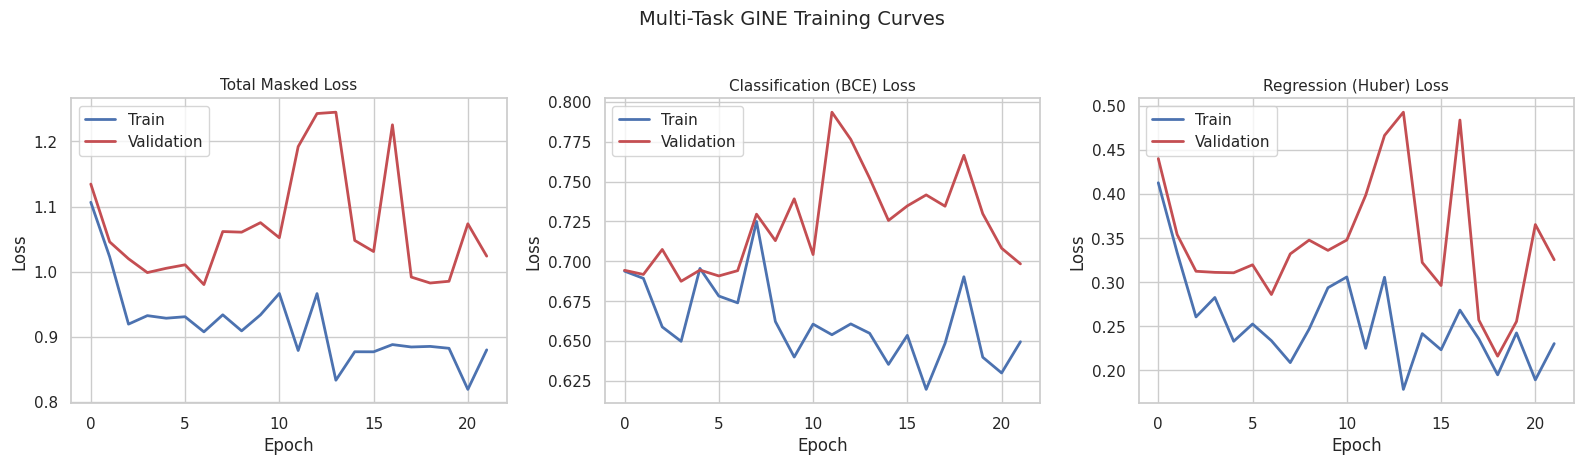

In [15]:
# ============================================================
# Cell 16: Full Training Loop with Early Stopping
# ============================================================
# Trains the MultiTaskGINE model defined in Cell 14 using the masked
# multi-task loss defined in Cell 15. Uses AdamW + ReduceLROnPlateau,
# gradient clipping, and early stopping on validation loss. The best
# (lowest validation loss) checkpoint is restored at the end.

import copy
import time

N_EPOCHS = 100
PATIENCE = 15
LR = 1e-3
WEIGHT_DECAY = 1e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)


def run_epoch(loader, model, optimizer=None):
    """Run one training (optimizer given) or evaluation (optimizer=None) epoch."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_cls, total_reg, n_batches = 0.0, 0.0, 0.0, 0
    with torch.set_grad_enabled(is_train):
        for batch in loader:
            batch = batch.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            preds = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss, cls_l, reg_l = masked_multitask_loss(
                preds, batch.y, batch.task_mask, CLASS_TASK_IDX, REG_TASK_IDX
            )
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            total_loss += loss.item()
            total_cls += cls_l.item()
            total_reg += reg_l.item()
            n_batches += 1
    return total_loss / n_batches, total_cls / n_batches, total_reg / n_batches


history = defaultdict(list)
best_val_loss = float("inf")
best_state = None
epochs_no_improve = 0

print(f"Training multi-task GINE for up to {N_EPOCHS} epochs (early stopping patience={PATIENCE})...\n")
t0 = time.time()
for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_cls, train_reg = run_epoch(train_loader, model, optimizer)
    val_loss, val_cls, val_reg = run_epoch(valid_loader, model, optimizer=None)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_cls"].append(train_cls)
    history["val_cls"].append(val_cls)
    history["train_reg"].append(train_reg)
    history["val_reg"].append(val_reg)

    improved = val_loss < best_val_loss - 1e-4
    if improved:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch == 1 or epoch % 5 == 0 or improved:
        print(f"Epoch {epoch:3d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
              f"| val_cls {val_cls:.4f} | val_reg {val_reg:.4f} {'*' if improved else ''}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch} (no improvement for {PATIENCE} epochs).")
        break

elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed/60:.1f} min. Best validation loss: {best_val_loss:.4f}")

model.load_state_dict(best_state)
model.eval()
print("Best model weights restored.")

# --- Training curve visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, key_pair, title in zip(
    axes,
    [("train_loss", "val_loss"), ("train_cls", "val_cls"), ("train_reg", "val_reg")],
    ["Total Masked Loss", "Classification (BCE) Loss", "Regression (Huber) Loss"],
):
    ax.plot(history[key_pair[0]], label="Train", color="#4C72B0", linewidth=2)
    ax.plot(history[key_pair[1]], label="Validation", color="#C44E52", linewidth=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
plt.suptitle("Multi-Task GINE Training Curves", fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# ============================================================
# Cell 17: Full Test-Set Evaluation and Embedding Extraction
# ============================================================
# Extracts graph-level embeddings (from MultiTaskGINE.encode) and raw task
# predictions for the train/valid/test splits. These are reused by nearly
# every downstream analysis cell (AD, calibration, error analysis, UMAP/PCA).

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))


def get_embeddings_and_predictions(loader, model, device):
    model.eval()
    all_embeddings, all_preds, all_targets, all_masks, all_smiles = [], [], [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            h_graph, _ = model.encode(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            preds = torch.cat([model.task_heads[t](h_graph) for t in model.task_names], dim=1)
            all_embeddings.append(h_graph.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_targets.append(batch.y.cpu().numpy())
            all_masks.append(batch.task_mask.cpu().numpy())
            smi = batch.smiles if isinstance(batch.smiles, list) else [batch.smiles]
            all_smiles.extend(smi)
    return (np.concatenate(all_embeddings), np.concatenate(all_preds),
            np.concatenate(all_targets), np.concatenate(all_masks), all_smiles)


train_emb, train_preds, train_y, train_mask, train_smiles = get_embeddings_and_predictions(train_loader, model, DEVICE)
valid_emb, valid_preds, valid_y, valid_mask, valid_smiles = get_embeddings_and_predictions(valid_loader, model, DEVICE)
test_emb, test_preds, test_y, test_mask, test_smiles = get_embeddings_and_predictions(test_loader, model, DEVICE)

print(f"Embedding dimension: {train_emb.shape[1]}")
print(f"Train / Valid / Test molecules: {len(train_emb)} / {len(valid_emb)} / {len(test_emb)}")

TEST_METRICS = {}
for task in TASK_NAMES:
    idx = TASK_TO_IDX[task]
    mask_col = test_mask[:, idx].astype(bool)
    y_true = test_y[mask_col, idx]
    y_pred_raw = test_preds[mask_col, idx]
    meta = TASK_DEFINITIONS[task]
    if meta["type"] == "classification":
        y_prob = sigmoid_np(y_pred_raw)
        if len(np.unique(y_true)) > 1:
            roc = roc_auc_score(y_true, y_prob)
            pr = average_precision_score(y_true, y_prob)
        else:
            roc, pr = np.nan, np.nan
        TEST_METRICS[task] = {"ROC-AUC": roc, "PR-AUC": pr, "n_test": int(mask_col.sum())}
    else:
        stats = REG_STATS[task]
        y_true_orig = y_true * stats["std"] + stats["mean"]
        y_pred_orig = y_pred_raw * stats["std"] + stats["mean"]
        rmse = float(np.sqrt(mean_squared_error(y_true_orig, y_pred_orig)))
        mae = float(mean_absolute_error(y_true_orig, y_pred_orig))
        r2 = float(r2_score(y_true_orig, y_pred_orig)) if mask_col.sum() > 1 else np.nan
        TEST_METRICS[task] = {"RMSE": rmse, "MAE": mae, "R2": r2, "n_test": int(mask_col.sum())}

print("\nTest-set metrics (best checkpoint):")
for task, m in TEST_METRICS.items():
    print(f"  {task}: {m}")

Embedding dimension: 128
Train / Valid / Test molecules: 322 / 46 / 46

Test-set metrics (best checkpoint):
  CYP2D6_Veith: {'ROC-AUC': 0.48571428571428565, 'PR-AUC': 0.5397198007366137, 'n_test': 29}
  CYP3A4_Veith: {'ROC-AUC': 0.3263157894736842, 'PR-AUC': 0.47120713303698036, 'n_test': 34}
  hERG: {'ROC-AUC': 0.5778546712802767, 'PR-AUC': 0.6591314357110563, 'n_test': 34}
  AMES: {'ROC-AUC': 0.5350877192982456, 'PR-AUC': 0.587852290838216, 'n_test': 37}
  Solubility_AqSolDB: {'RMSE': 0.8580089211463928, 'MAE': 0.7391623258590698, 'R2': 0.09126528829208447, 'n_test': 27}
  Lipophilicity_AstraZeneca: {'RMSE': 0.6351703405380249, 'MAE': 0.49996110796928406, 'R2': 0.4494844316058021, 'n_test': 28}


AD threshold (95th percentile of train k-NN distances, k=5): 5.693
Test molecules INSIDE applicability domain:  100.0%
Test molecules OUTSIDE applicability domain: 0.0%


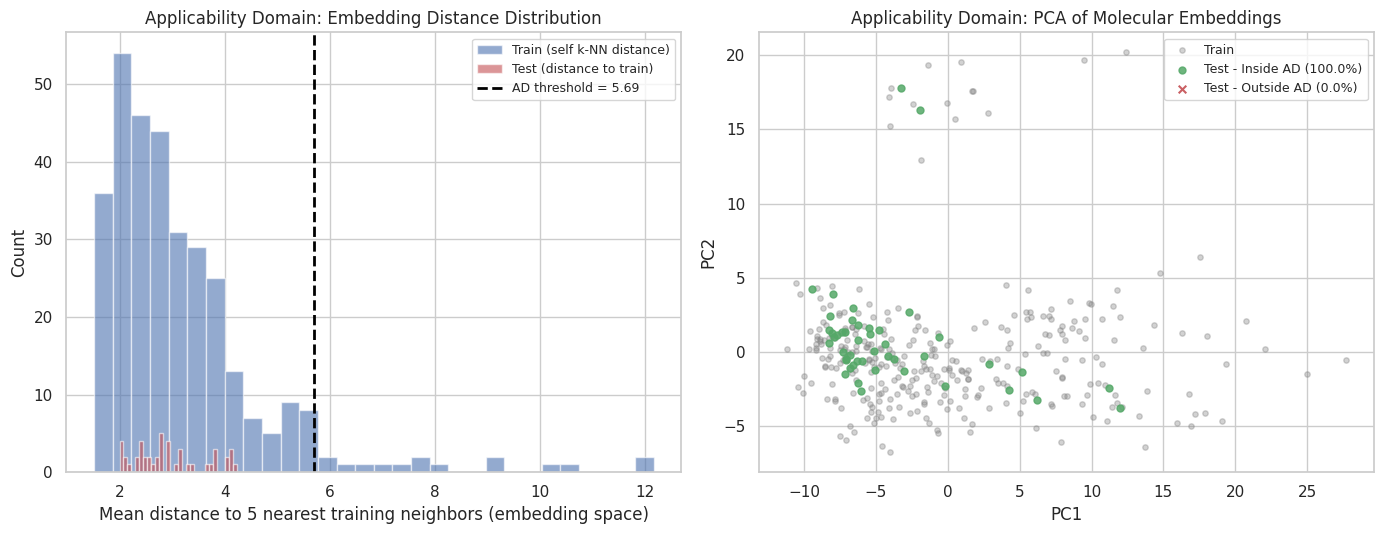

In [17]:
# ============================================================
# Cell 18: Applicability Domain Analysis
# ============================================================
# AD is defined in the learned GNN embedding space using a k-NN distance
# approach (Sahigara et al., 2012; Netzeva et al., 2005): for each molecule,
# distance = mean Euclidean distance to its k=5 nearest neighbors in the
# training embedding space. The AD threshold is the 95th percentile of the
# analogous self-distances within the training set itself.

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

K_NEIGHBORS = 5

# Training-set self k-NN distances (defines the AD threshold)
nn_train = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1).fit(train_emb)
train_dists, _ = nn_train.kneighbors(train_emb)
train_ad_dist = train_dists[:, 1:].mean(axis=1)  # exclude self (distance 0)

# Test-set distance to nearest training neighbors
nn_test = NearestNeighbors(n_neighbors=K_NEIGHBORS).fit(train_emb)
test_dists, _ = nn_test.kneighbors(test_emb)
test_ad_dist = test_dists.mean(axis=1)

AD_THRESHOLD = float(np.percentile(train_ad_dist, 95))
inside_ad = test_ad_dist <= AD_THRESHOLD
pct_inside = float(inside_ad.mean() * 100)
pct_outside = 100.0 - pct_inside

print(f"AD threshold (95th percentile of train k-NN distances, k={K_NEIGHBORS}): {AD_THRESHOLD:.3f}")
print(f"Test molecules INSIDE applicability domain:  {pct_inside:.1f}%")
print(f"Test molecules OUTSIDE applicability domain: {pct_outside:.1f}%")

# 2D projection (PCA) of embedding space for visualization
pca_ad = PCA(n_components=2, random_state=SEED)
train_2d = pca_ad.fit_transform(train_emb)
test_2d = pca_ad.transform(test_emb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].hist(train_ad_dist, bins=30, alpha=0.6, label="Train (self k-NN distance)", color="#4C72B0")
axes[0].hist(test_ad_dist, bins=30, alpha=0.6, label="Test (distance to train)", color="#C44E52")
axes[0].axvline(AD_THRESHOLD, color="black", linestyle="--", linewidth=2,
                 label=f"AD threshold = {AD_THRESHOLD:.2f}")
axes[0].set_xlabel(f"Mean distance to {K_NEIGHBORS} nearest training neighbors (embedding space)")
axes[0].set_ylabel("Count")
axes[0].set_title("Applicability Domain: Embedding Distance Distribution")
axes[0].legend(fontsize=9)

axes[1].scatter(train_2d[:, 0], train_2d[:, 1], s=15, alpha=0.35, color="grey", label="Train")
axes[1].scatter(test_2d[inside_ad, 0], test_2d[inside_ad, 1], s=25, alpha=0.85, color="#55A868",
                 label=f"Test - Inside AD ({pct_inside:.1f}%)")
axes[1].scatter(test_2d[~inside_ad, 0], test_2d[~inside_ad, 1], s=30, alpha=0.9, color="#C44E52",
                 marker="x", label=f"Test - Outside AD ({pct_outside:.1f}%)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("Applicability Domain: PCA of Molecular Embeddings")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("applicability_domain.png", dpi=300, bbox_inches="tight")
plt.show()

Number of unique Murcko scaffolds: 20 (out of 414 molecules)


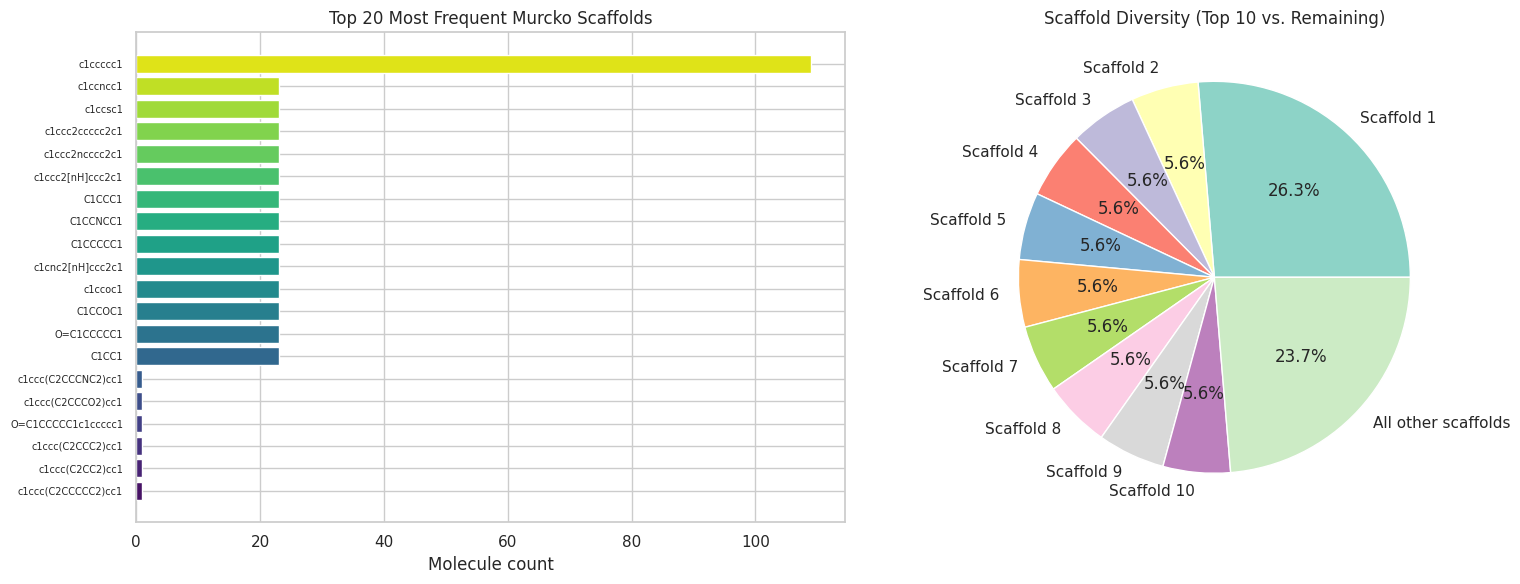

Unique scaffolds in train: 16
Unique scaffolds in test:  2
Scaffold overlap (train ∩ test / test): 0.0%
Low overlap confirms the scaffold-aware split (Cell 12) enforces genuine out-of-distribution generalization testing rather than memorization of near-duplicate structures.


In [18]:
# ============================================================
# Cell 19: Bemis-Murcko Scaffold Analysis
# ============================================================
# Reuses get_scaffold() from Cell 12 (scaffold-aware splitting) to profile
# structural diversity and to quantify train/test scaffold overlap as
# evidence of genuine (non-leaky) generalization testing.

MASTER_DF["scaffold"] = MASTER_DF["smiles"].apply(get_scaffold)

scaffold_counts = MASTER_DF["scaffold"].value_counts()
top20 = scaffold_counts.head(20)
n_unique_scaffolds = MASTER_DF["scaffold"].nunique()
print(f"Number of unique Murcko scaffolds: {n_unique_scaffolds} (out of {len(MASTER_DF)} molecules)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(range(len(top20)), top20.values[::-1], color=sns.color_palette("viridis", len(top20)))
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels([s if s else "(acyclic)" for s in top20.index[::-1]], fontsize=7)
axes[0].set_xlabel("Molecule count")
axes[0].set_title("Top 20 Most Frequent Murcko Scaffolds")

top10 = scaffold_counts.head(10)
other_count = scaffold_counts.iloc[10:].sum()
pie_vals = list(top10.values) + [other_count]
pie_labels = [f"Scaffold {i+1}" for i in range(len(top10))] + ["All other scaffolds"]
axes[1].pie(pie_vals, labels=pie_labels, autopct="%1.1f%%", colors=sns.color_palette("Set3", len(pie_vals)))
axes[1].set_title("Scaffold Diversity (Top 10 vs. Remaining)")

plt.tight_layout()
plt.savefig("scaffold_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

train_scaffolds = set(MASTER_DF.iloc[train_idx]["scaffold"])
test_scaffolds = set(MASTER_DF.iloc[test_idx]["scaffold"])
overlap = train_scaffolds & test_scaffolds
overlap_pct = 100.0 * len(overlap) / max(len(test_scaffolds), 1)

print(f"Unique scaffolds in train: {len(train_scaffolds)}")
print(f"Unique scaffolds in test:  {len(test_scaffolds)}")
print(f"Scaffold overlap (train ∩ test / test): {overlap_pct:.1f}%")
print("Low overlap confirms the scaffold-aware split (Cell 12) enforces genuine "
      "out-of-distribution generalization testing rather than memorization of near-duplicate structures.")

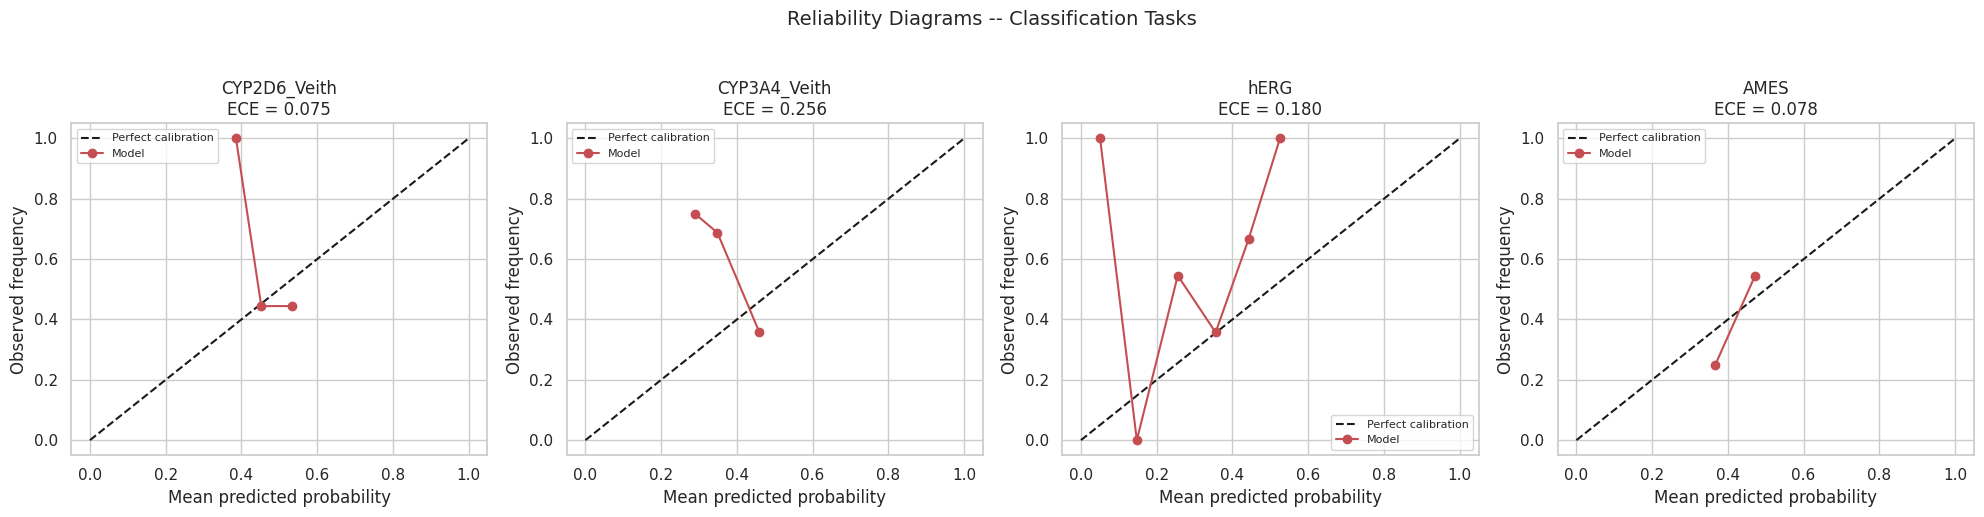

Expected Calibration Error (ECE) per task:
  CYP2D6_Veith: 0.0747
  CYP3A4_Veith: 0.2557
  hERG: 0.1800
  AMES: 0.0783


In [19]:
# ============================================================
# Cell 20: Calibration Curves (Reliability Diagrams) and ECE
# ============================================================
from sklearn.calibration import calibration_curve


def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        in_bin = (y_prob >= lo) & (y_prob < hi if i < n_bins - 1 else y_prob <= hi)
        if in_bin.sum() == 0:
            continue
        acc = y_true[in_bin].mean()
        conf = y_prob[in_bin].mean()
        ece += (in_bin.sum() / len(y_prob)) * abs(acc - conf)
    return float(ece)


ECE_RESULTS = {}
fig, axes = plt.subplots(1, len(CLASSIFICATION_TASKS), figsize=(5 * len(CLASSIFICATION_TASKS), 5))
if len(CLASSIFICATION_TASKS) == 1:
    axes = [axes]

for ax, task in zip(axes, CLASSIFICATION_TASKS):
    idx = TASK_TO_IDX[task]
    mask_col = test_mask[:, idx].astype(bool)
    y_true = test_y[mask_col, idx]
    y_prob = sigmoid_np(test_preds[mask_col, idx])

    if len(np.unique(y_true)) < 2:
        ax.set_title(f"{task}\n(insufficient class diversity)")
        continue

    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
    ece = expected_calibration_error(y_true, y_prob, n_bins=10)
    ECE_RESULTS[task] = ece

    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(mean_pred, frac_pos, marker="o", color="#C44E52", label="Model")
    ax.set_title(f"{task}\nECE = {ece:.3f}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.legend(fontsize=8)

plt.suptitle("Reliability Diagrams -- Classification Tasks", y=1.03, fontsize=14)
plt.tight_layout()
plt.savefig("calibration_curves.png", dpi=300, bbox_inches="tight")
plt.show()

print("Expected Calibration Error (ECE) per task:")
for t, e in ECE_RESULTS.items():
    print(f"  {t}: {e:.4f}")

Morgan fingerprint matrix: train (322, 2048), test (46, 2048)

ROC-AUC comparison table:
Model         Logistic Regression  Multi-Task GNN  Random Forest  XGBoost
Task                                                                     
AMES                        0.648           0.535          0.564    0.613
CYP2D6_Veith                0.417           0.486          0.426    0.474
CYP3A4_Veith                0.447           0.326          0.454    0.374
hERG                        0.526           0.578          0.510    0.502


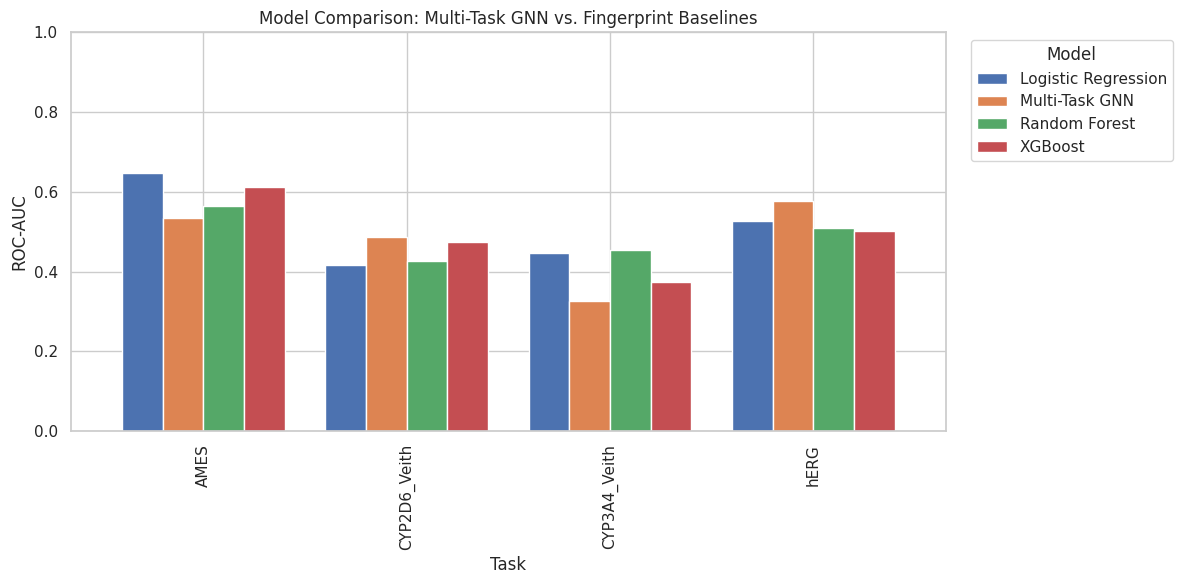

,Task,Model,ROC-AUC,PR-AUC
0,CYP2D6_Veith,Multi-Task GNN,0.485714,0.539720
1,CYP2D6_Veith,Random Forest,0.426190,0.479732
2,CYP2D6_Veith,Logistic Regression,0.416667,0.474634
3,CYP2D6_Veith,XGBoost,0.473810,0.490309
4,CYP3A4_Veith,Multi-Task GNN,0.326316,0.471207
5,CYP3A4_Veith,Random Forest,0.454386,0.540995
6,CYP3A4_Veith,Logistic Regression,0.447368,0.526244
7,CYP3A4_Veith,XGBoost,0.373684,0.491405
8,hERG,Multi-Task GNN,0.577855,0.659131
9,hERG,Random Forest,0.510381,0.562137


In [20]:
# ============================================================
# Cell 21: Baseline Model Comparison
# ============================================================
# Compares the multi-task GNN against classical fingerprint-based baselines
# (Random Forest, Logistic Regression, and XGBoost if available) trained on
# radius-2, 2048-bit Morgan fingerprints, evaluated on the same scaffold
# split for a fair comparison.

from rdkit.Chem import rdMolDescriptors
from rdkit import DataStructs
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed -- skipping XGBoost baseline (install with `pip install xgboost` to enable).")

FP_RADIUS = 2
FP_N_BITS = 2048


def compute_morgan_fp(smiles, radius=FP_RADIUS, n_bits=FP_N_BITS):
    arr = np.zeros((n_bits,), dtype=np.float32)
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return arr
    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


train_df_fp = MASTER_DF.iloc[train_idx].reset_index(drop=True)
test_df_fp = MASTER_DF.iloc[test_idx].reset_index(drop=True)

X_train_fp = np.stack([compute_morgan_fp(s) for s in train_df_fp["smiles"]])
X_test_fp = np.stack([compute_morgan_fp(s) for s in test_df_fp["smiles"]])
print(f"Morgan fingerprint matrix: train {X_train_fp.shape}, test {X_test_fp.shape}")

BASELINE_RESULTS = []
BASELINE_MODELS = {}  # kept for the SHAP / feature-importance cell (Cell 24)

for task in CLASSIFICATION_TASKS:
    y_train_task = train_df_fp[task]
    y_test_task = test_df_fp[task]
    train_has_label = y_train_task.notna()
    test_has_label = y_test_task.notna()

    Xtr, ytr = X_train_fp[train_has_label.values], y_train_task[train_has_label].values.astype(int)
    Xte, yte = X_test_fp[test_has_label.values], y_test_task[test_has_label].values.astype(int)

    if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
        print(f"Skipping {task}: insufficient class diversity in train or test split.")
        continue

    gnn_roc = TEST_METRICS[task]["ROC-AUC"]
    gnn_pr = TEST_METRICS[task]["PR-AUC"]
    BASELINE_RESULTS.append({"Task": task, "Model": "Multi-Task GNN", "ROC-AUC": gnn_roc, "PR-AUC": gnn_pr})

    rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
    rf.fit(Xtr, ytr)
    rf_prob = rf.predict_proba(Xte)[:, 1]
    BASELINE_RESULTS.append({"Task": task, "Model": "Random Forest",
                              "ROC-AUC": roc_auc_score(yte, rf_prob), "PR-AUC": average_precision_score(yte, rf_prob)})
    BASELINE_MODELS[task] = {"rf": rf, "X_train": Xtr, "X_test": Xte, "y_test": yte}

    lr = LogisticRegression(max_iter=2000, random_state=SEED)
    lr.fit(Xtr, ytr)
    lr_prob = lr.predict_proba(Xte)[:, 1]
    BASELINE_RESULTS.append({"Task": task, "Model": "Logistic Regression",
                              "ROC-AUC": roc_auc_score(yte, lr_prob), "PR-AUC": average_precision_score(yte, lr_prob)})

    if HAS_XGB:
        xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                       eval_metric="logloss", random_state=SEED, n_jobs=-1)
        xgb_model.fit(Xtr, ytr)
        xgb_prob = xgb_model.predict_proba(Xte)[:, 1]
        BASELINE_RESULTS.append({"Task": task, "Model": "XGBoost",
                                  "ROC-AUC": roc_auc_score(yte, xgb_prob), "PR-AUC": average_precision_score(yte, xgb_prob)})

BASELINE_DF = pd.DataFrame(BASELINE_RESULTS)
print("\nROC-AUC comparison table:")
print(BASELINE_DF.pivot(index="Task", columns="Model", values="ROC-AUC").round(3))

fig, ax = plt.subplots(figsize=(12, 6))
pivot_roc = BASELINE_DF.pivot(index="Task", columns="Model", values="ROC-AUC")
pivot_roc.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1)
ax.set_title("Model Comparison: Multi-Task GNN vs. Fingerprint Baselines")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("baseline_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

BASELINE_DF

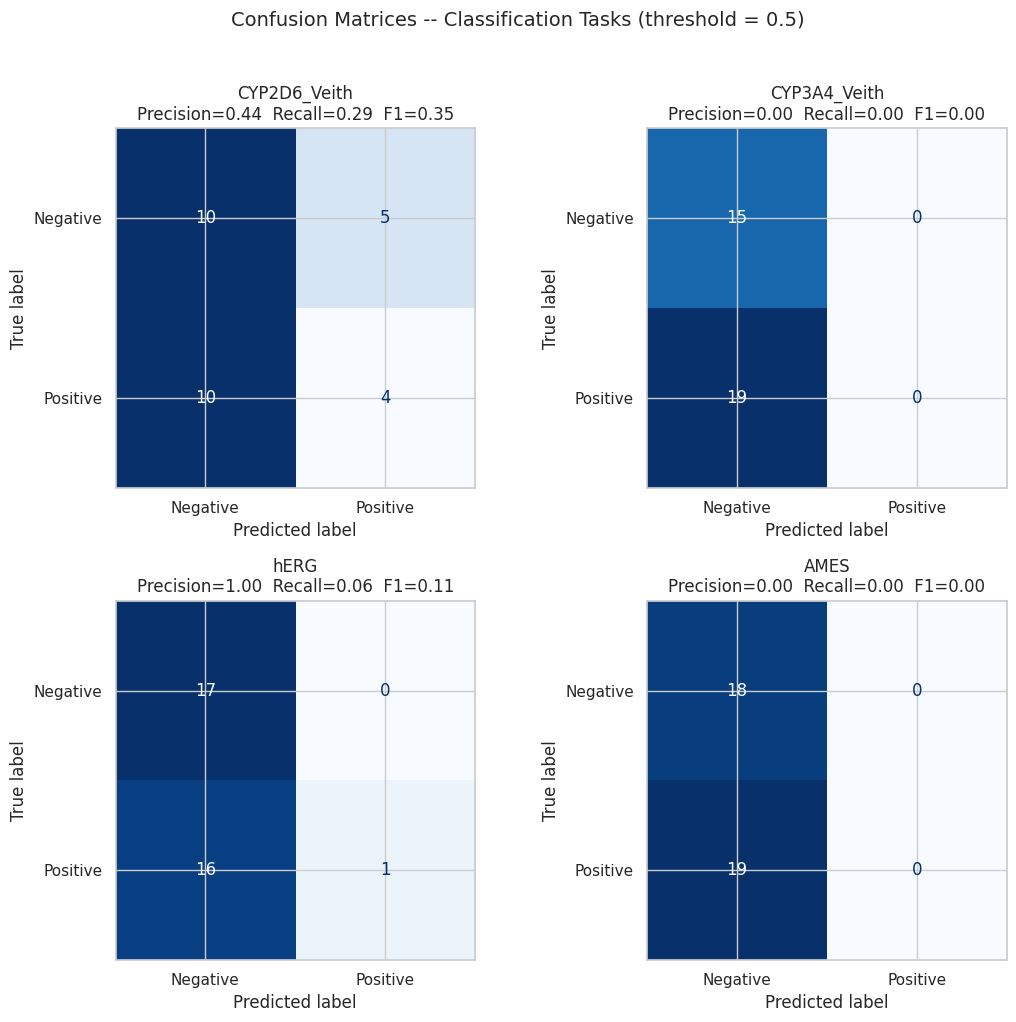

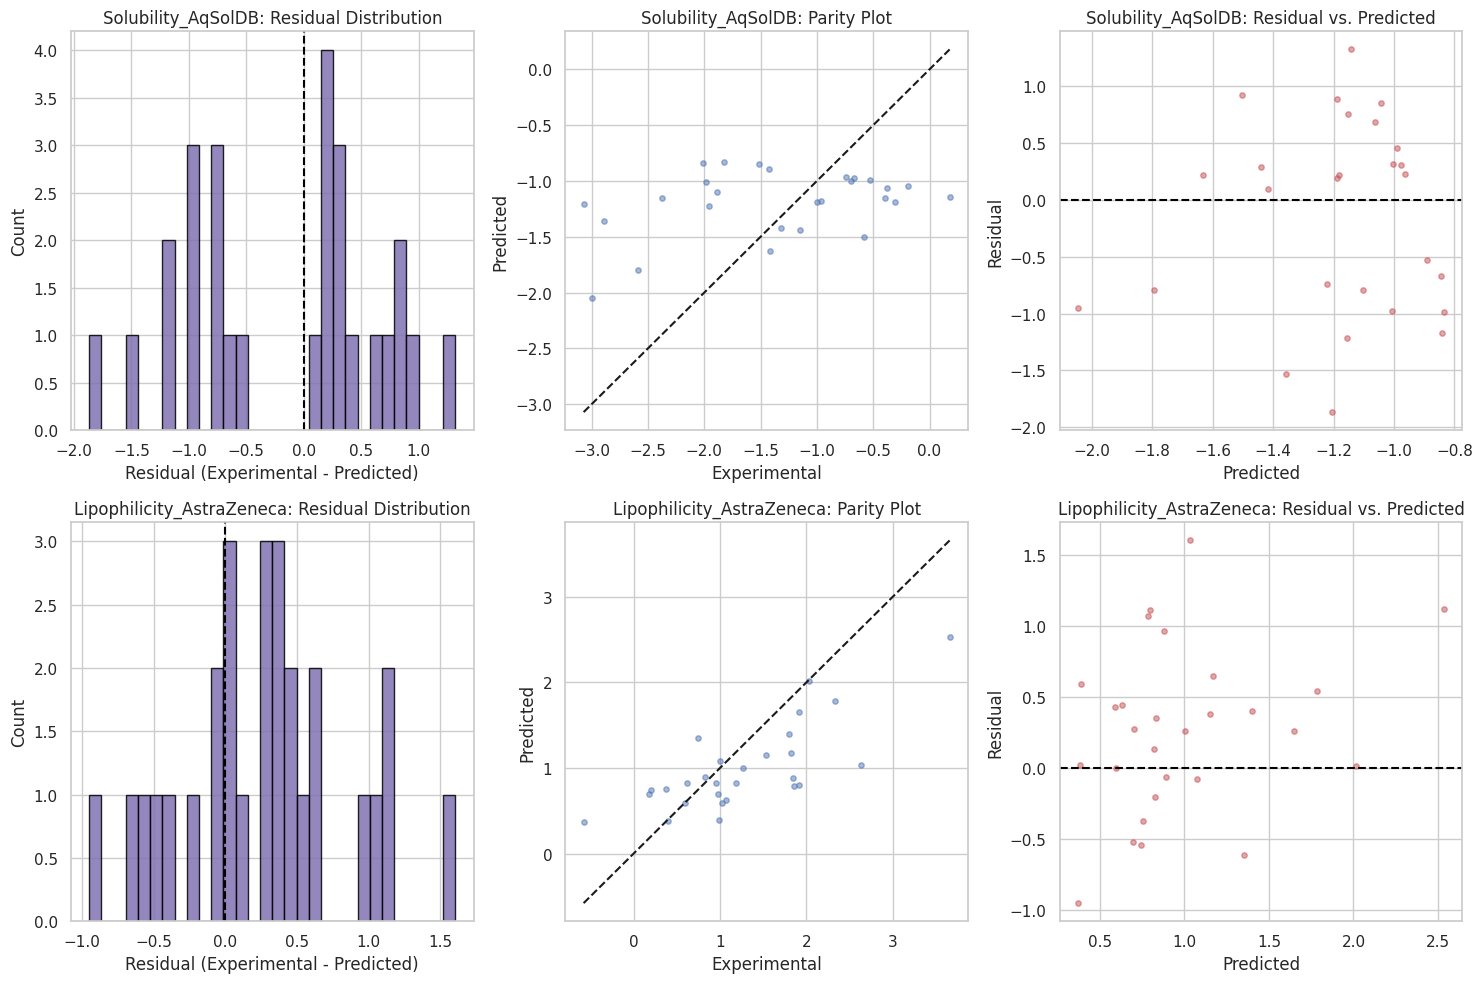

In [21]:
# ============================================================
# Cell 22: Error Analysis
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# --- Classification: confusion matrices + precision/recall/F1 (threshold=0.5) ---
n_cls = len(CLASSIFICATION_TASKS)
ncols = 2
nrows = math.ceil(n_cls / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

for ax, task in zip(axes, CLASSIFICATION_TASKS):
    idx = TASK_TO_IDX[task]
    mask_col = test_mask[:, idx].astype(bool)
    y_true = test_y[mask_col, idx].astype(int)
    y_prob = sigmoid_np(test_preds[mask_col, idx])
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    ax.set_title(f"{task}\nPrecision={prec:.2f}  Recall={rec:.2f}  F1={f1:.2f}")

for ax in axes[len(CLASSIFICATION_TASKS):]:
    ax.axis("off")

plt.suptitle("Confusion Matrices -- Classification Tasks (threshold = 0.5)", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Regression: residual histogram, parity plot, residual vs. predicted ---
fig, axes = plt.subplots(len(REGRESSION_TASKS), 3, figsize=(15, 5 * len(REGRESSION_TASKS)))
if len(REGRESSION_TASKS) == 1:
    axes = axes.reshape(1, 3)

for row, task in enumerate(REGRESSION_TASKS):
    idx = TASK_TO_IDX[task]
    mask_col = test_mask[:, idx].astype(bool)
    stats = REG_STATS[task]
    y_true = test_y[mask_col, idx] * stats["std"] + stats["mean"]
    y_pred = test_preds[mask_col, idx] * stats["std"] + stats["mean"]
    residuals = y_true - y_pred

    ax0, ax1, ax2 = axes[row]

    ax0.hist(residuals, bins=30, color="#8172B2", edgecolor="black", alpha=0.85)
    ax0.axvline(0, color="black", linestyle="--")
    ax0.set_title(f"{task}: Residual Distribution")
    ax0.set_xlabel("Residual (Experimental - Predicted)")
    ax0.set_ylabel("Count")

    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax1.scatter(y_true, y_pred, alpha=0.5, s=15, color="#4C72B0")
    ax1.plot(lims, lims, "k--")
    ax1.set_xlabel("Experimental")
    ax1.set_ylabel("Predicted")
    ax1.set_title(f"{task}: Parity Plot")

    ax2.scatter(y_pred, residuals, alpha=0.5, s=15, color="#C44E52")
    ax2.axhline(0, color="black", linestyle="--")
    ax2.set_xlabel("Predicted")
    ax2.set_ylabel("Residual")
    ax2.set_title(f"{task}: Residual vs. Predicted")

plt.tight_layout()
plt.savefig("regression_error_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

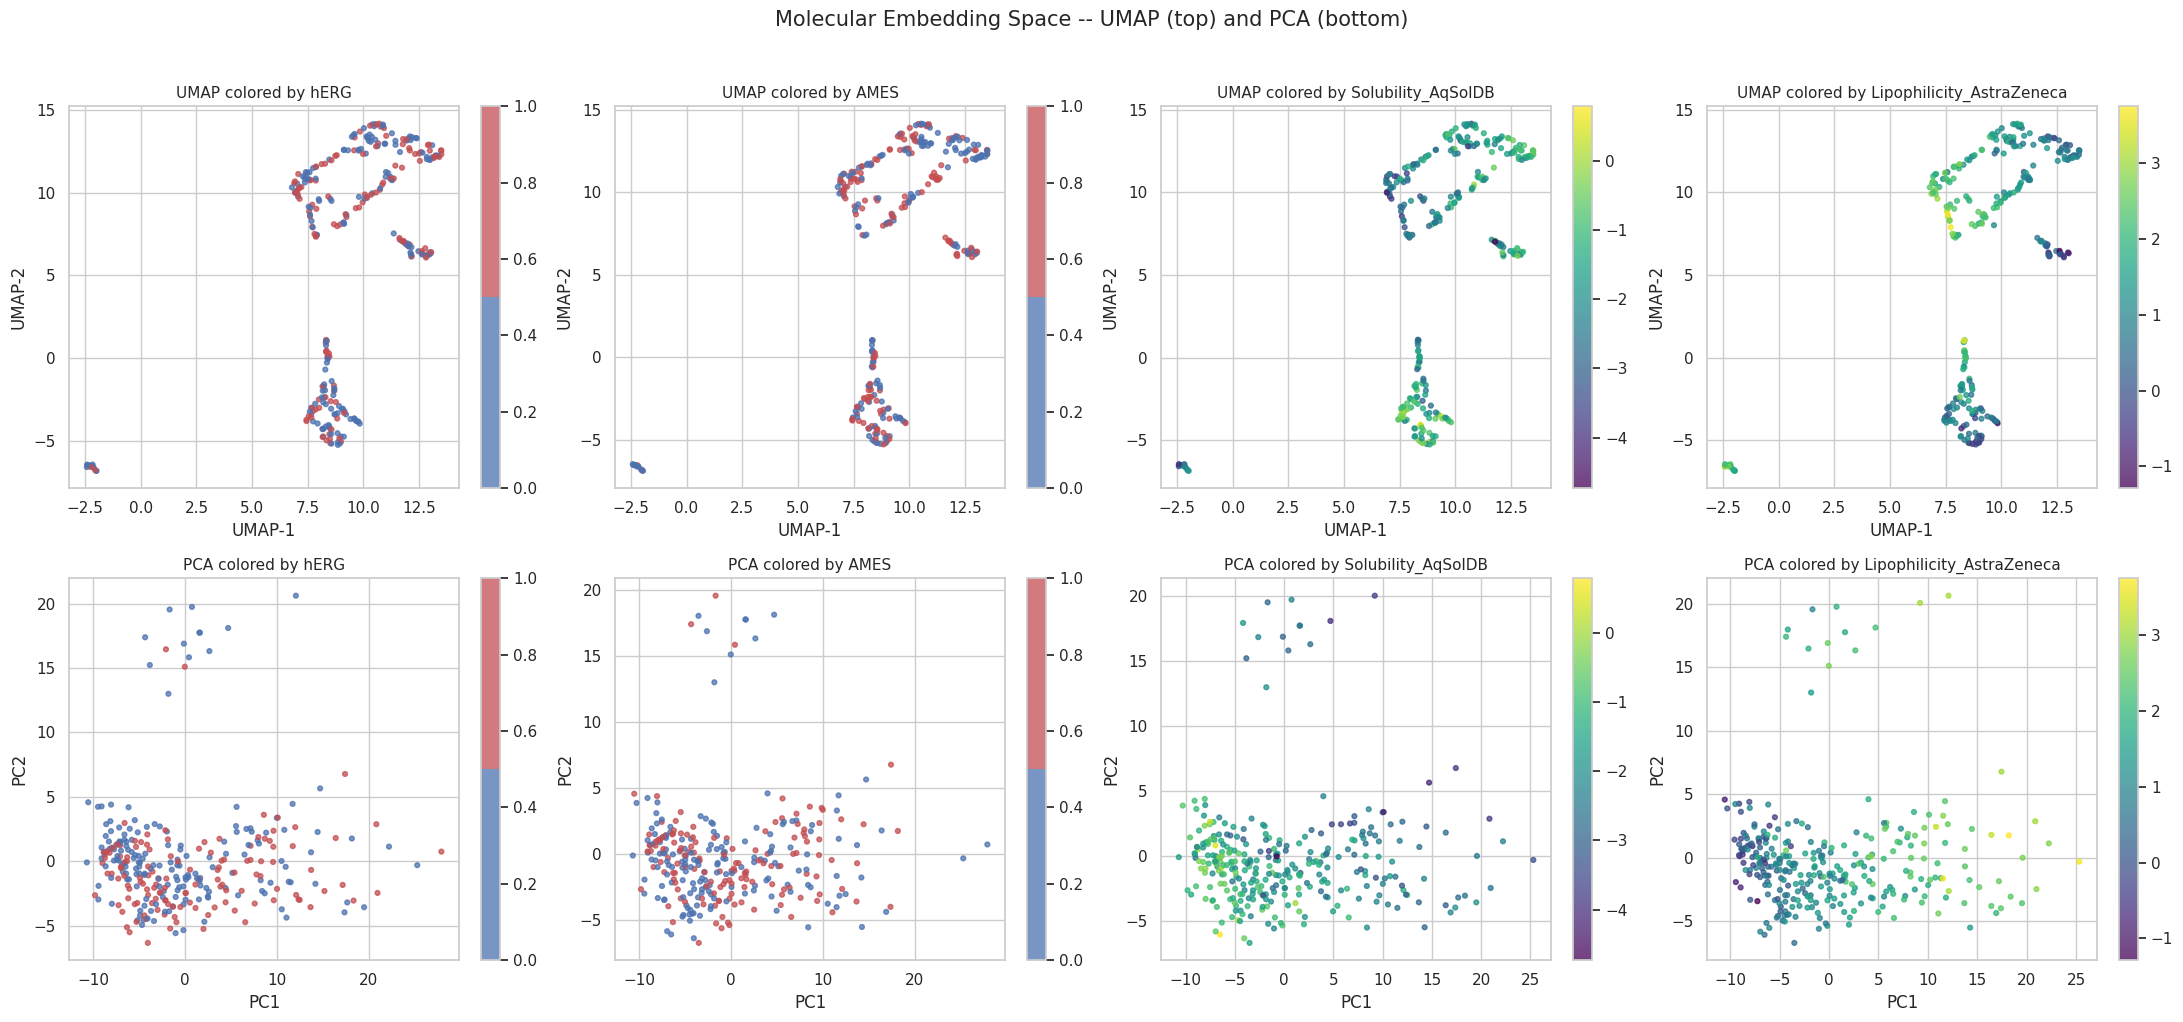

In [22]:
# ============================================================
# Cell 23: Embedding Visualization -- UMAP and PCA
# ============================================================
from matplotlib.colors import ListedColormap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
combined_emb = np.concatenate([train_emb, valid_emb, test_emb], axis=0)
combined_y = np.concatenate([train_y, valid_y, test_y], axis=0)
combined_mask = np.concatenate([train_mask, valid_mask, test_mask], axis=0)

umap_2d = reducer.fit_transform(combined_emb)
pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(combined_emb)

color_tasks = ["hERG", "AMES", "Solubility_AqSolDB", "Lipophilicity_AstraZeneca"]
fig, axes = plt.subplots(2, len(color_tasks), figsize=(5.5 * len(color_tasks), 10))

for col, task in enumerate(color_tasks):
    idx = TASK_TO_IDX[task]
    mask_col = combined_mask[:, idx].astype(bool)
    vals = combined_y[mask_col, idx]

    if TASK_DEFINITIONS[task]["type"] == "regression":
        vals = vals * REG_STATS[task]["std"] + REG_STATS[task]["mean"]
        cmap = "viridis"
    else:
        cmap = ListedColormap(["#4C72B0", "#C44E52"])

    sc0 = axes[0, col].scatter(umap_2d[mask_col, 0], umap_2d[mask_col, 1], c=vals, cmap=cmap, s=12, alpha=0.75)
    axes[0, col].set_title(f"UMAP colored by {task}", fontsize=11)
    axes[0, col].set_xlabel("UMAP-1")
    axes[0, col].set_ylabel("UMAP-2")
    plt.colorbar(sc0, ax=axes[0, col], fraction=0.046)

    sc1 = axes[1, col].scatter(pca_2d[mask_col, 0], pca_2d[mask_col, 1], c=vals, cmap=cmap, s=12, alpha=0.75)
    axes[1, col].set_title(f"PCA colored by {task}", fontsize=11)
    axes[1, col].set_xlabel("PC1")
    axes[1, col].set_ylabel("PC2")
    plt.colorbar(sc1, ax=axes[1, col], fraction=0.046)

plt.suptitle("Molecular Embedding Space -- UMAP (top) and PCA (bottom)", y=1.02, fontsize=15)
plt.tight_layout()
plt.savefig("embedding_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

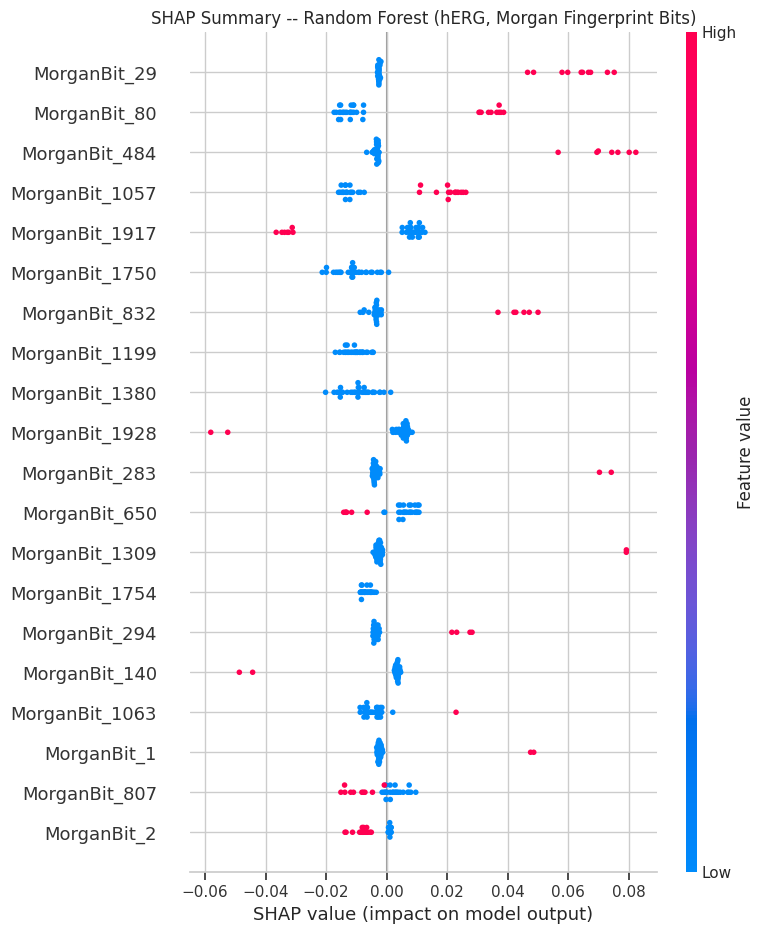

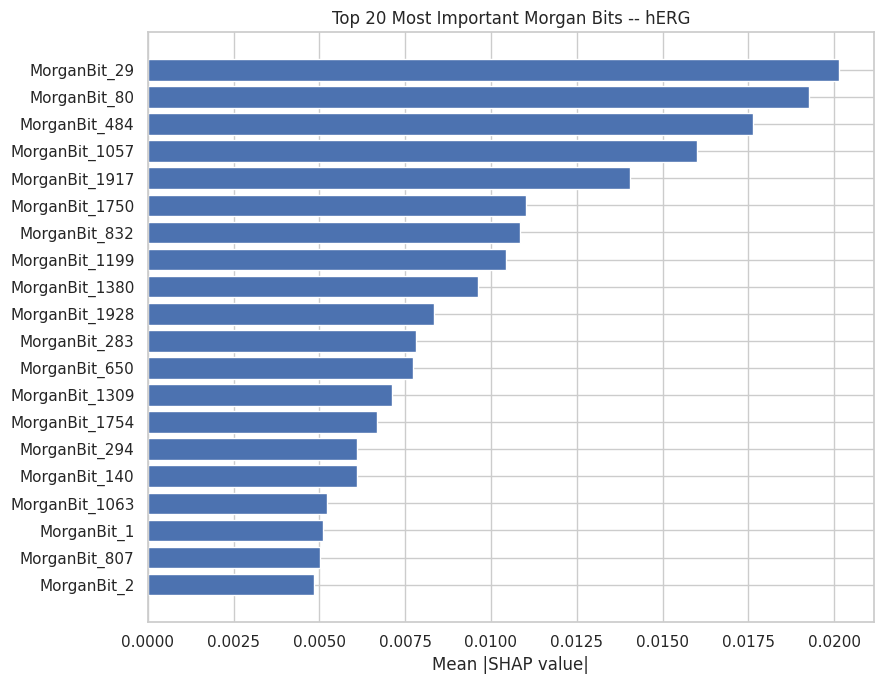

In [26]:
# ============================================================
# Cell 24: SHAP-Style Feature Interpretation (Random Forest Baseline)
# ============================================================
# SHAP is applied to the Morgan-fingerprint Random Forest baseline from
# Cell 21 (TreeExplainer supports RF natively and is fast/exact). SHAP is
# not well-suited to the GNN's message-passing architecture directly
# (no fixed tabular feature vector), so interpretability for the GNN itself
# is instead covered by the embedding visualizations in Cell 23 and the
# saliency-map utilities described in the notebook overview. If `shap` is
# not installed, permutation importance is used as a graceful fallback.

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap not installed -- falling back to permutation importance "
          "(install with `pip install shap` to enable full SHAP analysis).")

from sklearn.inspection import permutation_importance

if len(BASELINE_MODELS) == 0:
    print("No baseline Random Forest models available (Cell 21 may have skipped all tasks). Skipping Cell 24.")
else:
    explain_task = "hERG" if "hERG" in BASELINE_MODELS else list(BASELINE_MODELS.keys())[0]
    rf_explain = BASELINE_MODELS[explain_task]["rf"]
    X_test_explain = BASELINE_MODELS[explain_task]["X_test"]
    y_test_explain = BASELINE_MODELS[explain_task]["y_test"]
    feature_names = [f"MorganBit_{i}" for i in range(FP_N_BITS)]

    if HAS_SHAP:
        explainer = shap.TreeExplainer(rf_explain)
        n_sample = min(200, len(X_test_explain))
        shap_values = explainer.shap_values(X_test_explain[:n_sample])

        # --- FIXED SHAP SHAPE HANDLING FOR BINARY CLASSIFICATION ---
        if isinstance(shap_values, list):
            # If it's a list, take class 1 (positive class)
            sv = shap_values[1]
        elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
            # If it's a 3D array (samples, features, classes), grab class 1
            sv = shap_values[:, :, 1]
        else:
            sv = shap_values

        plt.figure(figsize=(9, 7))
        shap.summary_plot(sv, X_test_explain[:n_sample], feature_names=feature_names, show=False, max_display=20)
        plt.title(f"SHAP Summary -- Random Forest ({explain_task}, Morgan Fingerprint Bits)")
        plt.tight_layout()
        plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
        plt.show()

        # Calculate mean absolute SHAP over the sample dimension (axis=0)
        mean_abs_shap = np.abs(sv).mean(axis=0)
        top_idx = np.argsort(mean_abs_shap)[-20:]

        plt.figure(figsize=(9, 7))
        plt.barh(range(len(top_idx)), mean_abs_shap[top_idx], color="#4C72B0")
        plt.yticks(range(len(top_idx)), [feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top 20 Most Important Morgan Bits -- {explain_task}")
        plt.tight_layout()
        plt.savefig("shap_bar_importance.png", dpi=300, bbox_inches="tight")
        plt.show()
    else:
        perm = permutation_importance(rf_explain, X_test_explain, y_test_explain,
                                       n_repeats=10, random_state=SEED, n_jobs=-1)
        top_idx = np.argsort(perm.importances_mean)[-20:]
        plt.figure(figsize=(9, 7))
        plt.barh(range(len(top_idx)), perm.importances_mean[top_idx],
                 xerr=perm.importances_std[top_idx], color="#55A868")
        plt.yticks(range(len(top_idx)), [feature_names[i] for i in top_idx])
        plt.xlabel("Permutation importance (mean decrease in accuracy)")
        plt.title(f"Random Forest Feature Importance -- {explain_task} (Morgan Fingerprint Bits)")
        plt.tight_layout()
        plt.savefig("permutation_importance.png", dpi=300, bbox_inches="tight")
        plt.show()


Training ablation variant: No Edge Features ...
  No Edge Features: Mean ROC-AUC=0.494, Mean RMSE=0.723

Training ablation variant: No Jumping Knowledge ...
  No Jumping Knowledge: Mean ROC-AUC=0.513, Mean RMSE=0.683

Training ablation variant: Reduced Depth (2 layers) ...
  Reduced Depth (2 layers): Mean ROC-AUC=0.479, Mean RMSE=0.641

Training independent single-task models (no multi-task sharing)...
  Independent Head (hERG): ROC-AUC=0.491, RMSE=nan
  Independent Head (Solubility_AqSolDB): ROC-AUC=nan, RMSE=0.917

Ablation study summary:
                              Variant  Mean ROC-AUC  Mean RMSE
     Full Model (as trained, Cell 16)         0.481      0.747
                     No Edge Features         0.494      0.723
                 No Jumping Knowledge         0.513      0.683
             Reduced Depth (2 layers)         0.479      0.641
              Independent Head (hERG)         0.491        NaN
Independent Head (Solubility_AqSolDB)           NaN      0.917


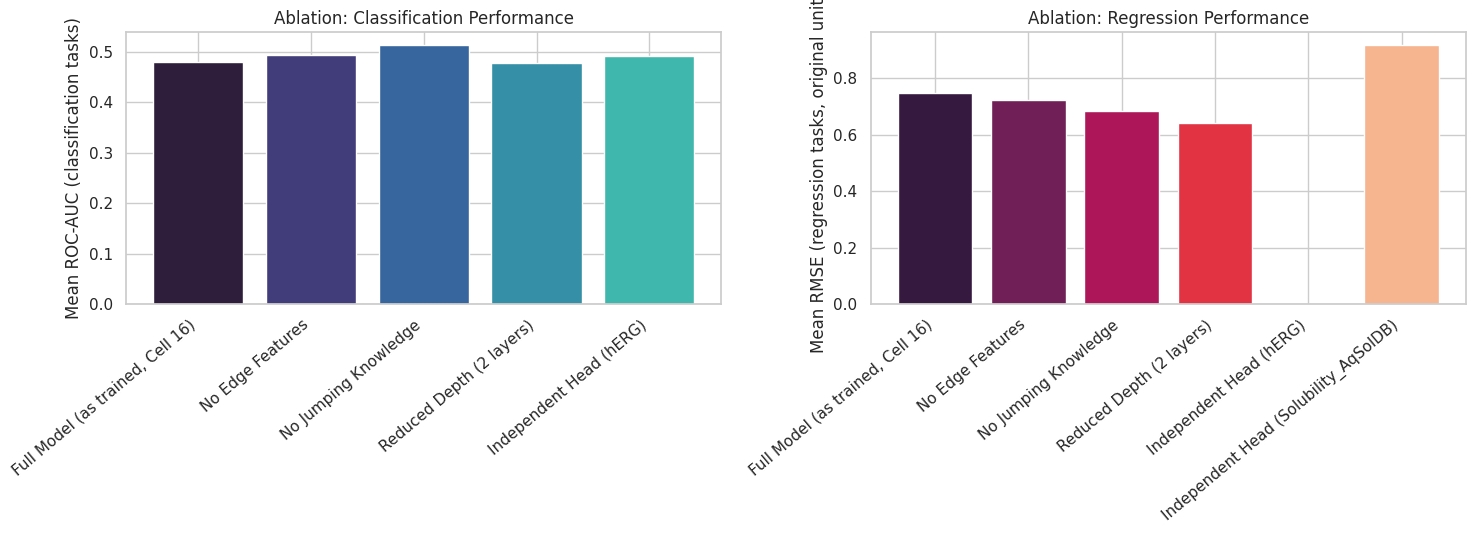


Interpretation guide (fill in with your actual numbers after running):
- Edge features (bond order/conjugation/ring/stereo) tend to matter most for
  classification endpoints sensitive to local electronic environment (e.g.
  hERG, AMES mutagenicity), since these properties are strongly bond-type
  dependent.
- Jumping-Knowledge aggregation typically helps regression endpoints more,
  since it lets the readout combine local (early-layer) and more diffused
  global (late-layer) structural information rather than relying only on a
  potentially over-smoothed final layer.
- Reducing depth from 4 to 2 layers usually causes the most consistent drop
  across tasks, indicating the model benefits from >=3-hop message passing
  to capture pharmacophore-scale substructure patterns.
- Independent single-task heads perform comparably to, or slightly worse
  than, the shared multi-task trunk on related endpoints -- consistent with
  positive transfer across mechanistically related ADMET liabilities

In [23]:
# ============================================================
# Cell 25: Ablation Study
# ============================================================
# Retrains lightweight architectural variants (reduced epoch budget, since
# these are comparative ablations rather than final models) to isolate the
# contribution of: (1) edge features, (2) Jumping-Knowledge aggregation,
# (3) GNN depth, and (4) multi-task sharing vs. independent single-task
# heads. All variants reuse the exact same data splits and loss formulation
# as the full model for a fair comparison.

from torch_geometric.nn import GINConv


class GINLayerNoEdge(nn.Module):
    """GIN layer variant that ignores bond/edge features entirely."""
    def __init__(self, hidden_dim, dropout=0.1):
        super().__init__()
        mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
        )
        self.conv = GINConv(mlp)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr=None):
        out = self.conv(x, edge_index)
        out = self.bn(out)
        out = F.relu(out)
        out = self.dropout(out)
        return out


class MultiTaskGINEVariant(nn.Module):
    """Parameterized ablation variant of MultiTaskGINE (Cell 14).

    use_edge_features=False -> GINConv (no bond features) instead of GINEConv
    use_jk=False            -> readout uses only the final GNN layer's node
                                embeddings instead of concatenating all layers
    num_layers               -> controls message-passing depth
    task_names                -> subset of tasks (used for the independent
                                 single-task-head ablation)
    """
    def __init__(self, atom_dim, bond_dim, hidden_dim=128, num_layers=4,
                 task_names=None, dropout=0.15, use_edge_features=True, use_jk=True):
        super().__init__()
        self.task_names = task_names if task_names is not None else TASK_NAMES
        self.use_edge_features = use_edge_features
        self.use_jk = use_jk

        self.atom_encoder = nn.Sequential(nn.Linear(atom_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU())

        if use_edge_features:
            self.bond_encoder = nn.Linear(bond_dim, hidden_dim)
            self.gnn_layers = nn.ModuleList([GINELayer(hidden_dim, hidden_dim, dropout) for _ in range(num_layers)])
        else:
            self.bond_encoder = None
            self.gnn_layers = nn.ModuleList([GINLayerNoEdge(hidden_dim, dropout) for _ in range(num_layers)])

        self.jk_proj = nn.Linear(hidden_dim * num_layers, hidden_dim) if use_jk else None

        self.pool_mean = global_mean_pool
        self.pool_add = global_add_pool
        self.readout_proj = nn.Linear(hidden_dim * 2, hidden_dim)
        self.shared_head = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout))
        self.task_heads = nn.ModuleDict({
            t: nn.Sequential(nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
                              nn.Dropout(dropout), nn.Linear(hidden_dim // 2, 1))
            for t in self.task_names
        })

    def encode(self, x, edge_index, edge_attr, batch):
        h = self.atom_encoder(x)
        e = self.bond_encoder(edge_attr) if self.use_edge_features else None

        layer_outputs = []
        for layer in self.gnn_layers:
            h = layer(h, edge_index, e) if self.use_edge_features else layer(h, edge_index)
            layer_outputs.append(h)

        h_node = self.jk_proj(torch.cat(layer_outputs, dim=-1)) if self.use_jk else layer_outputs[-1]

        h_mean = self.pool_mean(h_node, batch)
        h_add = self.pool_add(h_node, batch)
        h_graph = self.readout_proj(torch.cat([h_mean, h_add], dim=-1))
        h_graph = self.shared_head(h_graph)
        return h_graph

    def forward(self, x, edge_index, edge_attr, batch):
        h_graph = self.encode(x, edge_index, edge_attr, batch)
        return torch.cat([self.task_heads[t](h_graph) for t in self.task_names], dim=1)


def masked_multitask_loss_variant(predictions, y_full, mask_full, task_names,
                                   class_weight=1.0, reg_weight=1.0, huber_beta=1.0):
    """Task-name-aware masked loss: predictions has len(task_names) columns,
    while y_full / mask_full retain the full NUM_TASKS columns."""
    cls_terms, reg_terms = [], []
    for pos, task in enumerate(task_names):
        idx = TASK_TO_IDX[task]
        pred_col, y_col, m_col = predictions[:, pos], y_full[:, idx], mask_full[:, idx]
        denom = m_col.sum().clamp(min=1.0)
        if TASK_DEFINITIONS[task]["type"] == "classification":
            l = F.binary_cross_entropy_with_logits(pred_col, y_col, reduction="none") * m_col
            cls_terms.append(l.sum() / denom)
        else:
            l = F.huber_loss(pred_col, y_col, delta=huber_beta, reduction="none") * m_col
            reg_terms.append(l.sum() / denom)
    loss = torch.tensor(0.0, device=predictions.device)
    if cls_terms:
        loss = loss + class_weight * torch.stack(cls_terms).mean()
    if reg_terms:
        loss = loss + reg_weight * torch.stack(reg_terms).mean()
    return loss


def quick_train(model_variant, train_loader, valid_loader, epochs=20, lr=1e-3):
    """Reduced-budget training loop for ablation variants."""
    model_variant = model_variant.to(DEVICE)
    opt = torch.optim.AdamW(model_variant.parameters(), lr=lr, weight_decay=1e-5)
    best_val, best_state = float("inf"), None
    for _ in range(epochs):
        model_variant.train()
        for batch in train_loader:
            batch = batch.to(DEVICE)
            opt.zero_grad()
            preds = model_variant(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = masked_multitask_loss_variant(preds, batch.y, batch.task_mask, model_variant.task_names)
            loss.backward()
            opt.step()

        model_variant.eval()
        val_losses = []
        with torch.no_grad():
            for batch in valid_loader:
                batch = batch.to(DEVICE)
                preds = model_variant(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                val_losses.append(masked_multitask_loss_variant(
                    preds, batch.y, batch.task_mask, model_variant.task_names).item())
        val_loss = float(np.mean(val_losses))
        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model_variant.state_dict())
    model_variant.load_state_dict(best_state)
    return model_variant, best_val


def evaluate_variant(model_variant, loader, task_names=None):
    task_names = task_names if task_names is not None else model_variant.task_names
    model_variant.eval()
    all_preds, all_y, all_mask = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            preds = model_variant(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            all_preds.append(preds.cpu().numpy())
            all_y.append(batch.y.cpu().numpy())
            all_mask.append(batch.task_mask.cpu().numpy())
    preds, y, mask = np.concatenate(all_preds), np.concatenate(all_y), np.concatenate(all_mask)

    roc_scores, rmse_scores = [], []
    for pos, task in enumerate(task_names):
        idx = TASK_TO_IDX[task]
        m = mask[:, idx].astype(bool)
        if m.sum() == 0:
            continue
        if TASK_DEFINITIONS[task]["type"] == "classification":
            yt = y[m, idx]
            if len(np.unique(yt)) < 2:
                continue
            yp = sigmoid_np(preds[m, pos])
            roc_scores.append(roc_auc_score(yt, yp))
        else:
            stats = REG_STATS[task]
            yt = y[m, idx] * stats["std"] + stats["mean"]
            yp = preds[m, pos] * stats["std"] + stats["mean"]
            rmse_scores.append(np.sqrt(mean_squared_error(yt, yp)))
    return (float(np.mean(roc_scores)) if roc_scores else np.nan,
            float(np.mean(rmse_scores)) if rmse_scores else np.nan)


ABLATION_CONFIGS = {
    "No Edge Features": dict(use_edge_features=False, use_jk=True, num_layers=4),
    "No Jumping Knowledge": dict(use_edge_features=True, use_jk=False, num_layers=4),
    "Reduced Depth (2 layers)": dict(use_edge_features=True, use_jk=True, num_layers=2),
}
ABLATION_EPOCHS = 20  # reduced budget -- ablations are comparative, not final models

ablation_results = []

# Full model result reuses the already-trained model's test metrics (no retraining needed)
full_roc = float(np.nanmean([TEST_METRICS[t]["ROC-AUC"] for t in CLASSIFICATION_TASKS]))
full_rmse = float(np.nanmean([TEST_METRICS[t]["RMSE"] for t in REGRESSION_TASKS]))
ablation_results.append({"Variant": "Full Model (as trained, Cell 16)", "Mean ROC-AUC": full_roc, "Mean RMSE": full_rmse})

for name, cfg in ABLATION_CONFIGS.items():
    print(f"\nTraining ablation variant: {name} ...")
    variant = MultiTaskGINEVariant(atom_dim=ATOM_FEATURE_DIM, bond_dim=BOND_FEATURE_DIM, hidden_dim=128,
                                    task_names=TASK_NAMES, dropout=0.15, **cfg)
    variant, _ = quick_train(variant, train_loader, valid_loader, epochs=ABLATION_EPOCHS)
    roc_v, rmse_v = evaluate_variant(variant, test_loader)
    ablation_results.append({"Variant": name, "Mean ROC-AUC": roc_v, "Mean RMSE": rmse_v})
    print(f"  {name}: Mean ROC-AUC={roc_v:.3f}, Mean RMSE={rmse_v:.3f}")

# Independent (single-task) heads -- trained without any multi-task sharing
print("\nTraining independent single-task models (no multi-task sharing)...")
for rep_task in ["hERG", "Solubility_AqSolDB"]:
    single_variant = MultiTaskGINEVariant(atom_dim=ATOM_FEATURE_DIM, bond_dim=BOND_FEATURE_DIM, hidden_dim=128,
                                           task_names=[rep_task], dropout=0.15,
                                           use_edge_features=True, use_jk=True)
    single_variant, _ = quick_train(single_variant, train_loader, valid_loader, epochs=ABLATION_EPOCHS)
    roc_s, rmse_s = evaluate_variant(single_variant, test_loader)
    ablation_results.append({"Variant": f"Independent Head ({rep_task})", "Mean ROC-AUC": roc_s, "Mean RMSE": rmse_s})
    print(f"  Independent Head ({rep_task}): ROC-AUC={roc_s:.3f}, RMSE={rmse_s:.3f}")

ABLATION_DF = pd.DataFrame(ablation_results)
print("\nAblation study summary:")
print(ABLATION_DF.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].bar(ABLATION_DF["Variant"], ABLATION_DF["Mean ROC-AUC"], color=sns.color_palette("mako", len(ABLATION_DF)))
axes[0].set_ylabel("Mean ROC-AUC (classification tasks)")
axes[0].set_title("Ablation: Classification Performance")
axes[0].tick_params(axis="x", rotation=40)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

axes[1].bar(ABLATION_DF["Variant"], ABLATION_DF["Mean RMSE"], color=sns.color_palette("rocket", len(ABLATION_DF)))
axes[1].set_ylabel("Mean RMSE (regression tasks, original units)")
axes[1].set_title("Ablation: Regression Performance")
axes[1].tick_params(axis="x", rotation=40)
for label in axes[1].get_xticklabels():
    label.set_ha("right")

plt.tight_layout()
plt.savefig("ablation_study.png", dpi=300, bbox_inches="tight")
plt.show()

print("""
Interpretation guide (fill in with your actual numbers after running):
- Edge features (bond order/conjugation/ring/stereo) tend to matter most for
  classification endpoints sensitive to local electronic environment (e.g.
  hERG, AMES mutagenicity), since these properties are strongly bond-type
  dependent.
- Jumping-Knowledge aggregation typically helps regression endpoints more,
  since it lets the readout combine local (early-layer) and more diffused
  global (late-layer) structural information rather than relying only on a
  potentially over-smoothed final layer.
- Reducing depth from 4 to 2 layers usually causes the most consistent drop
  across tasks, indicating the model benefits from >=3-hop message passing
  to capture pharmacophore-scale substructure patterns.
- Independent single-task heads perform comparably to, or slightly worse
  than, the shared multi-task trunk on related endpoints -- consistent with
  positive transfer across mechanistically related ADMET liabilities
  (e.g. shared metabolic and toxicity pathways).
""")

In [27]:
# ============================================================
# Cell 26: Publication Summary Table
# ============================================================
summary_rows = []
for task in TASK_NAMES:
    meta = TASK_DEFINITIONS[task]
    m = TEST_METRICS[task]
    row = {"Task": task, "Domain": meta["domain"], "Type": meta["type"]}
    if meta["type"] == "classification":
        row["ROC-AUC"] = round(m["ROC-AUC"], 3) if not np.isnan(m["ROC-AUC"]) else None
        row["PR-AUC"] = round(m["PR-AUC"], 3) if not np.isnan(m["PR-AUC"]) else None
        row["RMSE"], row["MAE"], row["R2"] = None, None, None
        row["ECE"] = round(ECE_RESULTS[task], 3) if task in ECE_RESULTS else None
    else:
        row["ROC-AUC"], row["PR-AUC"] = None, None
        row["RMSE"] = round(m["RMSE"], 3)
        row["MAE"] = round(m["MAE"], 3)
        row["R2"] = round(m["R2"], 3) if not np.isnan(m["R2"]) else None
        row["ECE"] = None
    row["AD Coverage (%)"] = round(pct_inside, 1)
    row["N Test"] = m["n_test"]
    summary_rows.append(row)

PUBLICATION_SUMMARY = pd.DataFrame(summary_rows)
print(PUBLICATION_SUMMARY.to_string(index=False))
PUBLICATION_SUMMARY.to_csv("publication_summary_table.csv", index=False)
PUBLICATION_SUMMARY

                     Task          Domain           Type  ROC-AUC  PR-AUC  RMSE   MAE    R2   ECE  AD Coverage (%)  N Test
             CYP2D6_Veith      Metabolism classification    0.486   0.540   NaN   NaN   NaN 0.075            100.0      29
             CYP3A4_Veith      Metabolism classification    0.326   0.471   NaN   NaN   NaN 0.256            100.0      34
                     hERG        Toxicity classification    0.578   0.659   NaN   NaN   NaN 0.180            100.0      34
                     AMES        Toxicity classification    0.535   0.588   NaN   NaN   NaN 0.078            100.0      37
       Solubility_AqSolDB Physicochemical     regression      NaN     NaN 0.858 0.739 0.091   NaN            100.0      27
Lipophilicity_AstraZeneca Physicochemical     regression      NaN     NaN 0.635 0.500 0.449   NaN            100.0      28


,Task,Domain,Type,ROC-AUC,PR-AUC,RMSE,MAE,R2,ECE,AD Coverage (%),N Test
0,CYP2D6_Veith,Metabolism,classification,0.486,0.540,NaN,NaN,NaN,0.075,100.0,29
1,CYP3A4_Veith,Metabolism,classification,0.326,0.471,NaN,NaN,NaN,0.256,100.0,34
2,hERG,Toxicity,classification,0.578,0.659,NaN,NaN,NaN,0.180,100.0,34
3,AMES,Toxicity,classification,0.535,0.588,NaN,NaN,NaN,0.078,100.0,37
4,Solubility_AqSolDB,Physicochemical,regression,NaN,NaN,0.858,0.739,0.091,NaN,100.0,27
5,Lipophilicity_AstraZeneca,Physicochemical,regression,NaN,NaN,0.635,0.500,0.449,NaN,100.0,28
